In [88]:
#Libraries
import pandas as pd
import numpy as np
import os
from scipy import stats
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import het_arch
from scipy.stats import jarque_bera, skew, kurtosis
from sklearn.metrics import r2_score
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model

In [ ]:
# Define the file path pattern (adjust if needed)
#drive.mount('/content/drive')
base_path = "/Users/tanmasleigh/Documents/Projects/GAMMA/Gamma/"

# List to store DataFrames
data_frames = []

# Loop through years 2012 to 2021
for year in range(2012, 2022):
    file_path = os.path.join(base_path, f'DAT_ASCII_EURUSD_M1_{year}.csv')
    
    # Read CSV file (adjust parameters if needed)
    df = pd.read_csv(file_path, header=None, sep=';')
    
    # Append to list
    data_frames.append(df)

# Concatenate all DataFrames into one
data = pd.concat(data_frames, ignore_index=True)

# Display first few rows to confirm
print(data.head())

In [ ]:
data.tail()

In [ ]:
data.shape

In [ ]:
# Rename columns for clarity
data.columns = ['DateTime', 'Open', 'High', 'Low', 'Close', 'Volume']

In [ ]:
data.tail(4)

In [ ]:
# Convert 'DateTime' to datetime format
data['DateTime'] = pd.to_datetime(data['DateTime'], format='%Y%m%d %H%M%S')

In [ ]:
#Checking for duplicate timestamps
counts = data['DateTime'].value_counts()
print(counts[counts > 1])

In [ ]:
# 1) Make a boolean mask for every duplicated timestamp (marking all occurrences)
dup_mask = data['DateTime'].duplicated(keep=False)

# 2) Subset and sort so we see each duplicated group in one place
dupe_rows = data.loc[dup_mask].sort_values('DateTime')

print(dupe_rows)


In [ ]:
# Setting DateTime to index
data.set_index('DateTime', inplace=True)
print(data.head())

# Ensure 'DateTime' is the index
data.index = pd.to_datetime(data.index)

# Generate a full range of 1-minute timestamps
full_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='1T')
full_range

In [ ]:
# Find missing timestamps
missing_timestamps = full_range.difference(data.index)   # Identifies missing timestamps

# Display missing timestamps
print(f"Missing Timestamps:\n{missing_timestamps}")


In [ ]:
# All missing timestamps (including weekends)
missing_timestamps.shape

In [ ]:
# Convert missing timestamps to a DataFrame
missing_df = pd.DataFrame(missing_timestamps, columns=['DateTime'])

#marking every row as 1 by creating new column - indicator
missing_df['indicator'] = 1
missing_df

In [ ]:
# Generate a complete time range with 1-minute frequency
# Instead of data['DateTime'], use data.index to access the DateTime values
full_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='T')

In [ ]:
# Create a dataframe from the complete time range
complete_df = pd.DataFrame(full_range, columns=['DateTime'])

# Merge the original dataframe with the complete time range
combined_df = pd.merge(complete_df, data, on='DateTime', how='left')

# Merge the missing dataframe with the combined dataframe
combined_df = pd.merge(combined_df, missing_df, on='DateTime', how='left')
combined_df

In [ ]:
# Fill the 'indicator' column: 0 for non-missing, 1 for missing
combined_df['indicator'] = combined_df['indicator'].fillna(0).astype(int)

# Sort by DateTime (optional)
combined_df = combined_df.sort_values(by='DateTime').reset_index(drop=True)
combined_df

In [ ]:
# Count 1's in indicator column
count_ones = combined_df['indicator'].sum()
print(f"Number of 1's in indicator column: {count_ones}")

In [ ]:
#######    EXPLANATORY DATA ANALYSIS   #######

In [ ]:
'''
####   DUPLICATED DATA ANALYSIS  #####
plt.figure(figsize=(22, 5))
plt.bar(dup_per_day.index, dup_per_day.values, color='purple')
plt.title('Duplicate Data Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Duplicate Price Occurrences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Plot duplicate occurrences per day
plt.figure(figsize=(22, 5))
dup_per_day.plot(kind='bar', color='purple')
plt.title('Duplicate Data Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Duplicate Price Occurrences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
'''

In [ ]:
#DUPLICATED DATA PLOTS

# Ensure DateTime is in datetime format
combined_df['DateTime'] = pd.to_datetime(combined_df['DateTime'])

# Identify duplicated consecutive OHLC prices
dup_consecutive = combined_df[['Open', 'High', 'Low', 'Close']].eq(combined_df[['Open', 'High', 'Low', 'Close']].shift(-1)).all(axis=1) | \
                  combined_df[['Open', 'High', 'Low', 'Close']].eq(combined_df[['Open', 'High', 'Low', 'Close']].shift(1)).all(axis=1)

dup_df = combined_df[dup_consecutive]

# Group duplicate occurrences by date
dup_per_day = dup_df.groupby(dup_df['DateTime'].dt.date).size()

#  Group by hour and count occurrences of duplicate data
dup_per_hour = dup_df.groupby(dup_df['DateTime'].dt.hour).size()

# 
plt.figure(figsize=(22, 5))
plt.bar(dup_per_day.index, dup_per_day.values, color='purple')
plt.title('Duplicate Data Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Duplicate Price Occurrences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot the bar chart for duplicate data occurrences per hour
plt.figure(figsize=(22, 5))
dup_per_hour.plot(kind='bar', color='purple')
plt.title('Duplicate Data Per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Duplicate Price Occurrences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#

# Ensure DateTime is in datetime format
combined_df['DateTime'] = pd.to_datetime(combined_df['DateTime'])

# Step 1: Group by date and sum the indicator column (missing minutes per day)
missing_per_day = combined_df.groupby(combined_df['DateTime'].dt.date)['indicator'].sum()

# Step 2: Identify weekdays (days with less than 400 missing data)
weekdays = missing_per_day[missing_per_day < 400].index       

# Step 3: Filter the dataframe to include only weekdays
weekday_df = combined_df[combined_df['DateTime'].dt.date.isin(weekdays)]

# Step 4: Group by hour and sum missing data
missing_per_hour_weekdays = weekday_df.groupby(weekday_df['DateTime'].dt.hour)['indicator'].sum()

# Step 5: Add year-wise grouping for better analysis
missing_per_day_yearly = combined_df.groupby([combined_df['DateTime'].dt.year, combined_df['DateTime'].dt.date])['indicator'].sum()

# --- PLOTS ---

plt.figure(figsize=(15, 5))
colors = ['blue' if date in weekdays else 'red' for date in missing_per_day.index]
plt.bar(missing_per_day.index, missing_per_day.values, color=colors)

plt.title('Weekdays vs Non-Weekdays Based on Missing Data (All Years)')
plt.xlabel('Date')
plt.ylabel('Number of Missing Minutes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4, label='Weekday (<400 missing)')
red_patch = plt.Line2D([0], [0], color='red', lw=4, label='Non-Weekday (>=400 missing)')
plt.legend(handles=[blue_patch, red_patch])
plt.tight_layout()
plt.show()


weekday_missing_data = missing_per_day[weekdays]
plt.figure(figsize=(15, 5))
plt.bar(weekday_missing_data.index, weekday_missing_data.values, color='blue')

plt.title('Missing Data Per Day in Weekdays (All Years)')
plt.xlabel('Date')
plt.ylabel('Missing Data')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Plot Step 4: Missing data per hour on weekdays
plt.figure(figsize=(12, 5))
missing_per_hour_weekdays.plot(kind='bar', color='red')
plt.title('Missing Data Per Hour on Weekdays (All Years)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Missing Minutes')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
missing_per_day

In [ ]:
# Group by month and sum the indicator column (missing minutes per month)
missing_per_month = combined_df.groupby(combined_df['DateTime'].dt.month)['indicator'].sum()

# Plot the bar chart
plt.figure(figsize=(35, 5))
missing_per_month.plot(kind='bar', color='red')
plt.title('Missing Data Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Missing Minutes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(missing_per_month)

In [ ]:
# We expect to have 4 weekends/ mo. Therefore 4*2*24*60 minutes missing per month = 11,520
sum(missing_per_month)-(11520*12)

In [ ]:
def remove_all_consecutive_duplicates(df):
    """Remove consecutive OHLC duplicates and flat bars with no price movement"""
    df_clean = df.copy()
    
    while True:
        # Check for consecutive duplicates
        prev_dup = (
            (df_clean['Open'] == df_clean['Open'].shift(1)) & 
            (df_clean['High'] == df_clean['High'].shift(1)) & 
            (df_clean['Low'] == df_clean['Low'].shift(1)) & 
            (df_clean['Close'] == df_clean['Close'].shift(1))
        )
        
        next_dup = (
            (df_clean['Open'] == df_clean['Open'].shift(-1)) & 
            (df_clean['High'] == df_clean['High'].shift(-1)) & 
            (df_clean['Low'] == df_clean['Low'].shift(-1)) & 
            (df_clean['Close'] == df_clean['Close'].shift(-1))
        )
        
        # Check for flat bars (no price movement)
        flat_bar = (
            (df_clean['Open'] == df_clean['High']) & 
            (df_clean['Open'] == df_clean['Low']) & 
            (df_clean['Open'] == df_clean['Close'])
        )
        
        # Combine conditions
        is_duplicate = prev_dup | next_dup | flat_bar
        count = is_duplicate.sum()
        
        if count == 0:
            break
            
        print(f"Marking {count} duplicates and flat bars…")

        # 1) blank out the OHLC
        df_clean.loc[is_duplicate, ['Open','High','Low','Close']] = np.nan
        df_clean.loc[is_duplicate, 'Volume'] = 0
        # 2) flag them
        df_clean.loc[is_duplicate, 'indicator'] = 1
        
    
    
    return df_clean

def remove_duplicate_timestamps(df):
    """
    Remove rows so that every DateTime is unique.
    Keeps the first occurrence of each timestamp and deletes all others.
    """
    df_clean = df.copy()

    while True:
        # Mark all rows whose DateTime appears more than once
        dup_mask = df_clean['DateTime'].duplicated(keep=False)
        if not dup_mask.any():
            break

        # Of those duplicates, keep only the first in each group
        to_remove = df_clean['DateTime'].duplicated(keep='first')
        count = to_remove.sum()
        print(f"Removing {count} rows with duplicate timestamps…")

        df_clean = df_clean.loc[~to_remove].reset_index(drop=True)

    return df_clean

def process_duplicated_data(df):
    """
    Process the DataFrame to remove duplicate timestamps and consecutive duplicates.
    """
    # Remove duplicate timestamps
    df = remove_duplicate_timestamps(df)

    # Remove consecutive duplicates and flat bars
    df = remove_all_consecutive_duplicates(df)

    return df


In [ ]:
final_data_clean = process_duplicated_data(combined_df)

In [ ]:
def check_dup(data):
    # Check for consecutive duplicates with previous row
    verify_prev = (
        (data['Open'] == data['Open'].shift(1)) & 
        (data['High'] == data['High'].shift(1)) & 
        (data['Low'] == data['Low'].shift(1)) & 
        (data['Close'] == data['Close'].shift(1))
    )
    
    # Check for consecutive duplicates with next row
    verify_next = (
        (data['Open'] == data['Open'].shift(-1)) & 
        (data['High'] == data['High'].shift(-1)) & 
        (data['Low'] == data['Low'].shift(-1)) & 
        (data['Close'] == data['Close'].shift(-1))
    )
    
    # Check for flat bars (no price movement)
    flat_bar = (
        (data['Open'] == data['High']) & 
        (data['Open'] == data['Low']) & 
        (data['Open'] == data['Close'])
    )
    
    # Count each type of duplicate
    consecutive_dups = (verify_prev | verify_next).sum()
    flat_bars = flat_bar.sum()
    total_dups = (verify_prev | verify_next | flat_bar).sum()
    
    print(f"Consecutive duplicates: {consecutive_dups}")
    print(f"Flat bars (no price movement): {flat_bars}")
    print(f"Total issues: {total_dups}")
    
    return total_dups

In [ ]:
check_dup(final_data_clean)

In [ ]:
final_data_clean

In [ ]:
final_data = final_data_clean.copy()
data = final_data
data

In [ ]:


# Plot the 'Close' prices
plt.figure(figsize=(12, 6))
plt.plot(data['DateTime'], data['Close'], label='Close Price', linewidth=1)

# Enhancing the plot aesthetics
plt.title('EUR/USD Close Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# Create a column to identify hourly groups
data['Hour'] = pd.to_datetime(data['DateTime']).dt.floor('h').dt.hour
data

In [ ]:
#Overall, the pipeline is:

#1. Drop days with too many missing minutes.

#2. Resample to your small minute_interval (e.g. 5 min) to form bars.

#3. Compute one per‐bar variance measure 𝑉

#4. Sum V and count bars in each large bucket of length timeframe.

#5. Turn that sum into an annualized realized volatility.

#6. Map it back onto every row, then collapse each bucket to a single row for plotting and statistical analysis.


def preprocess_ohlc_data(data, minute_interval):
    """
    Prepare OHLC data by properly formatting datetime and resampling to specified interval.
    For each timestamp, the interval is (timestamp - minute_interval + 1) to timestamp inclusive.
    For example, for 17:35:00 with 5-minute interval, we include [17:31:00 to 17:35:00].
    """
    # Ensure 'DateTime' is in datetime format
    data.reset_index(inplace=True)
    data['DateTime'] = pd.to_datetime(data['DateTime'], format='%Y%m%d %H%M%S')
    

    data = data.groupby(pd.Grouper(key='DateTime', freq=f'{minute_interval}Min',closed='right',label='right')).agg({
                                          "Open":  "first",
                                          "High":  "max",
                                          "Low":   "min",
                                         "Close": "last",
                                          "Volume": "sum",
                                          "indicator": "sum",
                                          "group_id":  lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan

                                          
                                          })
    return data
data


In [ ]:
def filter_incomplete_groups(ohlc_data, timeframe, threshold, vol_measure, minute_interval):
    """
    Filter out minutes within timeframe groups that exceed missing-data or are undersized.
    Before filtering, plots a scatter of available log-returns per group:
      • Green dots for groups with enough returns (≥ valid_returns_thresh)
      • Red dots for groups with too few returns (< valid_returns_thresh)
    The dashed horizontal line marks valid_returns_thresh.
    """
    # 1) Prepare & index
    ohlc = ohlc_data.copy()
    ohlc['DateTime'] = pd.to_datetime(ohlc['DateTime'], format='%Y%m%d %H%M%S')
    ohlc.set_index('DateTime', inplace=True)
    ohlc['group_id'] = ohlc.index.floor(f"{timeframe}T")

    # 2) Compute thresholds
    missing_thresh = timeframe * threshold               # max missing minutes
    valid_returns_thresh = timeframe - missing_thresh    # min log-returns needed

    # 3) Pre-filter metrics
    missing_counts = ohlc.groupby('group_id')['indicator'].sum()
    log_counts     = ohlc.groupby('group_id')['Log_Returns_global'] \
                         .apply(lambda x: x.notna().sum())

    # 4) Scatter plot of log-return counts
    passed = log_counts >= valid_returns_thresh
    plt.figure(figsize=(12, 5))
    plt.scatter(log_counts.index, log_counts.values,
                c=['green' if ok else 'red' for ok in passed],
                edgecolor='k', s=50)
    plt.axhline(y=valid_returns_thresh, color='black',
                linestyle='--', linewidth=2,
                label=f"Return-count threshold = {valid_returns_thresh:.0f}")
    plt.xticks(rotation=45)
    plt.xlabel('Group Start Time')
    plt.ylabel('Available Log-Returns')
    plt.title(
        f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min)\n"
        f"Log-Return Counts per {timeframe}-Minute Group (Pre-Filter)\n"
        f"Green  ≥{valid_returns_thresh:.0f} returns, Red  <{valid_returns_thresh:.0f}"
    ) 
    #plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # 5) Now simply select the green groups
    valid_groups = passed[passed].index
    filtered_data = ohlc[ohlc['group_id'].isin(valid_groups)].copy()
    
    # 6) Diagnostics
    print(f"Keeping {len(valid_groups)} groups (the green ones) out of {len(passed)} total.")
    
    return filtered_data


In [ ]:
def compute_volatility_measure(ohlc_data, vol_measure):
    """
    Calculate volatility using the specified method.
    
    Parameters:
    - ohlc_data (pd.DataFrame): OHLC data
    - vol_measure (str): Volatility measure ('Garman-Klass', 'Rogers-Satchell', 'Close-to-Close')
    
    Returns:
    - ohlc_data (pd.DataFrame): OHLC data with volatility measure added
    """
    # Make a copy to avoid modifying the input
    ohlc_data = ohlc_data.copy()
    
    # Constant for Garman-Klass
    k = 2 * np.log(2) - 1
    
    # Compute volatility measures (Variance)
    if vol_measure == 'Garman-Klass':
        ohlc_data['V'] = 0.5 * (np.log(ohlc_data['High'] / ohlc_data['Low']) ** 2) - \
                       k * (np.log(ohlc_data['Close'] / ohlc_data['Open']) ** 2)
    
    elif vol_measure == 'Rogers-Satchell':
        '''
        # Define prev close
        ohlc_data['Prev_Close'] = ohlc_data['Close'].shift(1)
        # Now compute Rogers–Satchell using Prev_Close (as before)
        ohlc_data['V'] = (
            np.log(ohlc_data['High']  / ohlc_data['Prev_Close']) *
            np.log(ohlc_data['High']  / ohlc_data['Close'])      +
            np.log(ohlc_data['Low']   / ohlc_data['Prev_Close']) *
            np.log(ohlc_data['Low']   / ohlc_data['Close'])
        )'''

        H, L, C = ohlc_data['High'], ohlc_data['Low'], ohlc_data['Close']
        P = ohlc_data['Prev_Close_global']   # <— from step 1
        ohlc_data['V'] = np.log(H/P)*np.log(H/C) + np.log(L/P)*np.log(L/C)
                        
    
    elif vol_measure == 'Close-to-Close':
        ohlc_data['V'] = ohlc_data['Log_Returns_global']**2
        #print(ohlc_data['V'])
    
    else:
        raise ValueError("Invalid volatility measure. Choose 'Garman-Klass', 'Rogers-Satchell', or 'Close-to-Close'.")
    
    return ohlc_data


In [ ]:
def setup_rvol_col(data, timeframe, vol_measure):
    """
    The overall purpose is to:
    1. Compute variance contributions for each row
    2. Calculate realized volatility for each group
    3. Attach the group's volatility to every row in that group
    """
    # 1) Compute per-bar variance contributions (V) for each row
    v_by_group = data.groupby('group_id')\
                     .apply(lambda grp: compute_volatility_measure(grp, vol_measure))
    
    # If it came back as a DataFrame, pick its 'V' column
    if isinstance(v_by_group, pd.DataFrame):
        v_series = v_by_group['V']
    else:
        v_series = v_by_group
    
    # Ensure index is consistent
    v_series = v_series.reset_index(level=0, drop=True)
    
    # 2) Attach per-bar V back onto a copy of your DataFrame
    df = data.copy()
    df['V'] = np.nan  # Preallocate
    df.loc[v_series.index, 'V'] = v_series
    
    # 3) Compute per-group sum of V and count of rows
    grp_stats = (
        df
        .groupby('group_id')['V']
        .agg(sum='sum', count='count')
    )
    print(grp_stats)
        # Sample variance WITHOUT using (n_minus_1)
    grp_stats['n_minus_1'] = grp_stats['count']
    grp_stats['var'] = np.where(
        grp_stats['n_minus_1'] > 0,
        grp_stats['sum'],
        np.nan
    )
    

    # 4) √variance → realized vol, annualize as before
    col_name = f'RVol_{timeframe}min_{vol_measure}'
    rvol_per_group = np.sqrt(grp_stats['var'])
    annualized_rvol = rvol_per_group * np.sqrt(365 * 24 * 60/ timeframe)

    # 5) Map both back onto every row
    df[col_name]    = df['group_id'].map(annualized_rvol)*100
    df['n_minus_1'] = df['group_id'].map(grp_stats['n_minus_1'])
    

    return df


In [ ]:
def plot_realized_volatility(rvol_df, vol_measure, timeframe, minute_interval):
    """
    Plot realized volatility over time.
    
    Parameters:
    - rvol_df (pd.DataFrame): DataFrame with realized volatility values
    - vol_measure (str): Volatility measure used
    - timeframe (int): Timeframe used for calculation
    """
    col_name = f'RVol_{timeframe}min_{vol_measure}'
    main_title = f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min)."
    log_vol = np.log(rvol_df[col_name])
    plt.figure(figsize=(30, 15))
    plt.scatter(rvol_df['EndDateTime'], log_vol, #rvol_df[col_name], 
               label=f'Realized Volatility ({vol_measure}, {timeframe} min)', 
               color='b', alpha=0.7)
    plt.xlabel('Time')
    plt.ylabel('Realized Volatility (%)')
    plt.title(f"{main_title}", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
def preprocess_by_group_id(rvol, vol_title):
    # Ensure 'DateTime' is in datetime format
    if isinstance(rvol.index, pd.DatetimeIndex):
        rvol.reset_index(inplace=True)
    
    # Convert DateTime if it's not already in datetime format
    if not pd.api.types.is_datetime64_any_dtype(rvol['DateTime']):
        rvol['DateTime'] = pd.to_datetime(rvol['DateTime'])
    
    # Group by group_id
    grouped = rvol.groupby('group_id')
    
    
    # Aggregate the data
    aggregated = grouped.agg({
        "DateTime": ["first", "last"],  # Keep first and last datetime for reference
        "Open": "first",                # First price in the group
        "High": "max",                  # Highest price in the group
        "Low": "min",                   # Lowest price in the group
        "Close": "last",                # Last price in the group
        "Volume": "sum",                # Sum of volume
        "indicator": "sum",             # Sum of indicator
        'n_minus_1': "mean",             # Mean of count
    })
    
    # Add vol_title aggregation explicitly
    #aggregated[vol_title] = grouped[vol_title].mean()
    
    #  — Compute mode of vol_title instead of mean:
    mode_series = grouped[vol_title].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    aggregated[vol_title] = mode_series.values
    
    # Flatten multi-level column names
    aggregated.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in aggregated.columns]
    
    # Rename datetime columns for clarity
    aggregated.rename(columns={
        'DateTime_first': 'StartDateTime',
        'DateTime_last': 'EndDateTime',
        'n_minus_1_mean': 'count'  
    }, inplace=True)

    # Reset index to make group_id a regular column
    aggregated.reset_index(inplace=True)
    #print(aggregated)
    #aggregated['count'] = aggregated['n_minus_1'] # Rename n_minus_1 to count for clarity
    return aggregated


In [ ]:
def plot_num_of_rows_per_group(df):
    
    plt.figure(figsize=(10, 6))
    plt.plot(df['group_id'], df['count'], marker='o', linestyle='', markersize=4)
    plt.xlabel('group_id')
    plt.ylabel('count of rows')
    plt.title('count vs. group_id')
    plt.grid(True)
    plt.show()


In [ ]:
def plot_rvol_histogram(rvol_data, timeframe, minute_interval, vol_measure, title_dates=None, bins=100):
    """
    Histogram of log(rVol) with:
      • green dashed = arithmetic mean
      • red dotted   = +1σ
      • red dashdot  = -1σ
    Stats‐box on left, legend on right, and date range as subtitle.
    """
    # 1) Series extraction & cleaning
    if isinstance(rvol_data, pd.DataFrame):
        series = rvol_data.iloc[:,0].dropna()
    else:
        series = rvol_data.dropna()
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    series = series[series > 0]
    if series.empty:
        print("No valid data to plot.")
        return

    # 2) Compute arithmetic stats
    mu_log = np.log(series).mean()
    sigma_log = np.log(series).std()
    sigma = np.exp(sigma_log)
    mu = np.exp(mu_log)

    # 3) Log-transform
    log_data = np.log(series)

    # 4) Plot
    fig, ax = plt.subplots(figsize=(10,6))
    ax.hist(log_data, bins=bins, edgecolor='k', alpha=0.7)

    # 5) Vertical lines
    ax.axvline(mu_log, color='green', linestyle='--', label=f"Mean = {mu:.4f}")
    ax.axvline(mu_log + sigma_log, color='red', linestyle=':', label=f"+1σ = {np.exp(mu_log + sigma_log):.4f}")
    ax.axvline(mu_log - sigma_log, color='red', linestyle='-.', label=f"−1σ = {np.exp(mu_log - sigma_log):.4f}")

    # 6) Stats‐box (left side)
    stats_text = (
        f"std: {sigma:.4f}\n"
        f"Min:  {series.min():.4f}\n"
        f"Max:  {series.max():.4f}\n"
        f"Skew: {skew(log_data):.2f}\n"
        f"Kurt: {kurtosis(log_data):.2f}"
    )
    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
            fontsize=10, va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # 7) Format x‐axis back to original scale
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{np.exp(x):.3f}"))
    
    rvol_actual = series[1:]

    # 8) Title & subtitle
    main_title = f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min)."
    third_title = f"Total # of Volatility Observed = {len(rvol_actual)}"
    if title_dates:
        start_str, end_str = title_dates
        subtitle = f"Date range: {start_str} to {end_str}. {third_title}"

    ax.set_title(main_title, fontsize=13, pad=20)
    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes,
            fontsize=11, ha='center')

    ax.set_xlabel("Realized Volatility (%)")
    ax.set_ylabel("# of Vols")

    # 9) Legend outside right
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

    # 10) Tight layout with room on right
    plt.tight_layout(rect=(0,0,0.8,1))
    plt.show()


In [ ]:
# Ensure DateTime is in datetime format and is a column

def plot_returns(data):
    time_col = 'DateTime'
    if 'EndDateTime' in data.columns:
        time_col = 'EndDateTime'
    elif 'StartDateTime' in data.columns:
        time_col = 'StartDateTime'
    elif 'DateTime' not in data.columns:
        raise KeyError("No valid time column found for plotting.")

    data['Prev_Close_global']  = data['Close_last'].shift(1)
    data['Prev_Close_global'].fillna(data['Open_first'], inplace=True)
    data['Log_Returns_global'] = np.log(data['Close_last'] / data['Prev_Close_global'])

    # Scatter plot of log returns
    plt.figure(figsize=(15, 6))
    plt.scatter(data[time_col], data['Log_Returns_global'], s=10, alpha=0.6)
    plt.title('EUR/USD Minute-by-Minute Log Returns Over Time')
    plt.xlabel('Time')
    plt.ylabel('Returns (%)')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.2%}'.format(x)))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_return_histogram(data):
    log_returns = data['Log_Returns_global'].dropna()*100

    # Stats
    mu    = log_returns.mean()
    sigma = log_returns.std()
    r_min = log_returns.min()
    r_max = log_returns.max()
    r_skew = skew(log_returns)
    r_kurt = kurtosis(log_returns)

    stats_text = (
        f"Mean:    {mu:.6f}\n"
        f"Std:     {sigma:.6f}\n"
        f"Min:     {r_min:.6f}\n"
        f"Max:     {r_max:.6f}\n"
        f"Skew:    {r_skew:.6f}\n"
        f"Kurtosis:{r_kurt:.6f}"
    )

    # Plot
    plt.figure(figsize=(12, 6))
    plt.hist(log_returns, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
    plt.axvline(mu, color='green', linestyle='--', linewidth=2, label=f"Mean")
    plt.axvline(mu + sigma, color='red', linestyle='--', linewidth=1.5, label='+1 Std')
    plt.axvline(mu - sigma, color='red', linestyle='--', linewidth=1.5, label='-1 Std')
    plt.title("EUR/USD Minute-by-Minute Log Returns Distribution")
    plt.xlabel("Returns (%)")
    plt.ylabel("Frequency")
    plt.legend(loc='upper right')
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.8))
     # Zoom in here
    plt.xlim(-1.5, 1.5) 
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
def analyze_volatility_prediction(rVol, rVol_pred, time,
                                  timeframe, vol_measure, minute_interval):

    # 1) log-ratio
    log_ratio_full = np.log(rVol / rVol_pred)#np.abs(np.log(rVol / rVol_pred))#np.log(rVol / rVol_pred)
    log_ratio_even = log_ratio_full.iloc[0::2]
    log_ratio_odd  = log_ratio_full.iloc[1::2]
    time_even, time_odd = time[0::2], time[1::2]

    # 2) per-slice stats
    def stats_dict(s):
        return dict(mean=s.mean(), std=s.std(), min=s.min(), max=s.max(),
                    skew=s.skew(), kurtosis=s.kurt())
    stats_even, stats_odd = stats_dict(log_ratio_even), stats_dict(log_ratio_odd)

    # 3) stats-text strings (create **before** plotting!)
    stats_text_even = (
        f"Even Indices:\n"
        f"Mean: {stats_even['mean']:.4f}\n"
        f"Std:  {stats_even['std'] :.4f}\n"
        f"Min:  {stats_even['min'] :.4f}\n"
        f"Max:  {stats_even['max'] :.4f}\n"
        f"Skew: {stats_even['skew']:.2f}\n"
        f"Kurt: {stats_even['kurtosis']:.2f}"
    )
    stats_text_odd = (
        f"Odd  Indices:\n"
        f"Mean: {stats_odd['mean']:.4f}\n"
        f"Std:  {stats_odd['std'] :.4f}\n"
        f"Min:  {stats_odd['min'] :.4f}\n"
        f"Max:  {stats_odd['max'] :.4f}\n"
        f"Skew: {stats_odd['skew']:.2f}\n"
        f"Kurt: {stats_odd['kurtosis']:.2f}"
    )

    # --------------------------------------------------
    # 4) SCATTER (odd vs even, centred at zero line)
    plt.figure(figsize=(12, 6))
    #plt.scatter(time_even, log_ratio_even, color='orange', alpha=0.6, label='Even indices')
    plt.scatter(time_odd , log_ratio_odd , color='blue'  , alpha=0.6, label='Odd indices')
    main = f"EURO/USD FX Rate rVol({timeframe} min rVol vs {minute_interval} min)"
    second_title = f"Predicted = Previous Trailing rVol"
    plt.title(f"{main}\nln(rVol / rVol_pred)\n{second_title}\n Total # of Vol observed = {len(log_ratio_full)}")
    plt.xlabel("Time");   plt.ylabel("Log-ratio error")
    plt.axhline(0, color='red', ls='--', lw=1)
    plt.legend(); plt.grid(alpha=.4, ls='--'); plt.tight_layout()  #legend
    plt.show()
    # --------------------------------------------------
    '''
    # 5) HISTOGRAM with right-hand sidebar
    fig, ax = plt.subplots(figsize=(12, 6))
    #ax.hist(log_ratio_even, bins=50, color='orange', alpha=.4, edgecolor='black', label='Even indices')
    ax.hist(log_ratio_odd , bins=50, color='blue'  , alpha=.6, edgecolor='black', label='Odd indices')

    ax.set_title(f"{main}\nDistribution of ln(rVol / rVol_pred)")
    ax.set_xlabel("Log Ratio"); ax.set_ylabel("Frequency")

    # reserve 22 % of figure for sidebar
    plt.tight_layout(rect=(0, 0, 0.98, 1))

    # legend in sidebar
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 1.5), frameon=False)

    # stats boxes in sidebar
    ax.text(1.02, 0.95, stats_text_odd,  transform=ax.transAxes,
            ha='left', va='top', bbox=dict(fc='white', ec='blue'  , alpha=.8))
    #ax.text(1.02, 0.60, stats_text_even, transform=ax.transAxes,
    #        ha='left', va='top', bbox=dict(fc='white', ec='orange', alpha=.8))

    ax.grid(alpha=.4, ls='--')
    plt.show()'''
    # 5) HISTOGRAM (clean version with only one distribution)
    fig, ax = plt.subplots(figsize=(10, 6))  # reduced width

    # Plot only the log-ratio values (previously called 'odd')
    ax.hist(log_ratio_odd, bins=50, color='steelblue', alpha=0.7, edgecolor='black')

    # Title and labels
    ax.set_title(f"{main}\nDistribution of ln(rVol / rVol_pred)")
    ax.set_xlabel("Log Ratio")
    ax.set_ylabel("Frequency")

    # Optional stats box
    ax.text(0.97, 0.95, stats_text_odd, transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(fc='white', ec='black', alpha=0.8))

    # Grid and layout
    ax.grid(alpha=0.4, linestyle='--')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------

    return {"odd": stats_odd, "even": stats_even}


In [ ]:
def plot_rvol_r2(rvol_data, vol_measure, timeframe, minute_interval, vol_title):
    """
    Uses the previous rVol value as the prediction and plots R² between predicted and actual rVol.
    
    Parameters:
    - rvol_series (pd.Series): A time series of realized volatility values.
    - title (str): Title of the plot.
    """
    rvol_data.set_index('EndDateTime', inplace=True)
    
    rvol_series = rvol_data[vol_title]
    # Clean the series: remove inf and NaN
   
    rvol_series = rvol_series.replace([np.inf, -np.inf], np.nan).dropna()
    #rvol_series = rvol_series.set_index('EndDateTime')[f'RVol_{timeframe}min_{vol_measure}']
    
    # Use lag-1 as prediction
    rvol_pred = rvol_series.shift(1).dropna()
    rvol_actual = rvol_series.iloc[1:]
    
    # Align indices
    rvol_pred = rvol_pred.loc[rvol_actual.index]
    
    # Final clean: ensure both have no inf or NaN
    mask = (~rvol_actual.isna()) & (~rvol_pred.isna()) & \
           (~np.isinf(rvol_actual)) & (~np.isinf(rvol_pred))
    rvol_actual = rvol_actual[mask]
    rvol_pred = rvol_pred[mask]
    
    # Check if there is enough data
    if len(rvol_actual) < 2:
        print("Not enough valid data to calculate R².")
        return None
    
    # R² Score
    r2 = r2_score(rvol_actual, rvol_pred)
    # ln R² Score
    ln_R2 = r2_score(np.log(rvol_actual), np.log(rvol_pred))
    
    '''
    # Plot 1: Predicted vs Actual (swapped axes)
    plt.figure(figsize=(8, 6))
    plt.scatter(rvol_pred, rvol_actual, alpha=0.5)  # Swapped axes here
    plt.xlabel('Predicted rVol')                    # Swapped label
    plt.ylabel('Actual rVol')                       # Swapped label
    plt.title(f'{title}\nCorrelation ($R^2$ = {r2:.4f})')
    plt.grid(True)
    plt.show()'''
    
    # Plot 2: Log-Log plot with original rVol labels (swapped axes)
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Calculate log values for plotting
    log_actual = np.log(rvol_actual)
    log_pred = np.log(rvol_pred)
    
    # Scatter plot of log values (swapped axes)
    ax.scatter(log_pred, log_actual, alpha=0.5)  # Swapped axes here
    
    # Set up custom tick locators and formatters to show original values
    from matplotlib.ticker import ScalarFormatter, LogLocator
    
    # Create formatters that will convert log values back to original scale for display
    class ExpFormatter(ScalarFormatter):
        def __call__(self, x, pos=None):
            # Convert log value to original value for display
            return f"{np.exp(x):.3f}"
    
    # Apply the formatters to both axes
    ax.xaxis.set_major_formatter(ExpFormatter())
    ax.yaxis.set_major_formatter(ExpFormatter())
    
    main_title = f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min). Actual vs Predicted"
    sub_title = f"Predicted = Previous Trailing rVol"
    third_title = f"Total # of Volatility Observed = {len(rvol_actual)}"
    title = f"{main_title}\n{sub_title}\n{third_title}"
    # Set labels and title (swapped labels)
    ax.set_xlabel('Predicted rVol (%)')                   # Swapped label
    ax.set_ylabel('Actual rVol (%)')                      # Swapped label
    ax.set_title(f'{title}')# = {ln_R2:.4f}')
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    stats = analyze_volatility_prediction(rvol_actual, rvol_pred, time=rvol_actual.index, minute_interval = minute_interval, timeframe = timeframe, vol_measure = vol_measure)
    
    return stats


In [ ]:
def calculate_rvol(data, vol_measure, timeframe, minute_interval, threshold, vol_title, plot=True):
    """

    Overall, the pipeline is:
    
    0. Prepare data with necessary columns (we are pushing each close price to the next row and labelling it Prev_Close_global)

    1. Drop timeframe groups with too many missing minutes.

    2. Resample to your small minute_interval (e.g. 5 min) to form bars. (for > 1 min intervals)

    3. Compute one per‐bar variance measure 𝑉

    4. Sum V and count bars in each large bucket of length timeframe.

    5. Turn that sum into an annualized realized volatility.

    6. Map it back onto every row, then collapse each bucket to a single row for plotting and statistical analysis.

    """
    # Input validation
    assert timeframe % 60 == 0, "Timeframe must be a multiple of 60 minutes."
    assert minute_interval > 0, "Minute interval must be positive."
    
    ### Step 0: Prepare data with necessary columns (we created a new col (Prev_Close_global) that is the previous period close price)
    ###                                             (we calculate log returns using Prev_Close_global)
    data['Prev_Close_global']  = data['Close'].shift(1)
    
    #### include logic to fill missing prev close with current open if prev close is NaN
    data['Prev_Close_global'].fillna(data['Open'], inplace=True)
    ####
    
    data['Log_Returns_global'] = np.log(data['Close'] / data['Prev_Close_global'])
    
    #print(data)
    
    # Step 1: Filter incomplete timeframe groups
    filtered_ohlc_data = filter_incomplete_groups(data, timeframe, threshold, vol_measure, minute_interval)
    
    # Step 2: Preprocess data
    #grouped_ohlc_data = preprocess_ohlc_data(filtered_ohlc_data, minute_interval)
    grouped_ohlc_data = filtered_ohlc_data.copy()
    # Step 3: Compute volatility measures
    compute_volatility_measure(grouped_ohlc_data, vol_measure)
    # Step 4: Aggregate into realized volatility
    rvol_df1 = setup_rvol_col(grouped_ohlc_data, timeframe, vol_measure)
    # Step 5: Preprocess by group_id
    rvol_df = preprocess_by_group_id(rvol_df1, vol_title = vol_title)

    plot_returns(rvol_df)
    plot_return_histogram(rvol_df)


    #print(rvol_df1)
    
    
    #plot_num_of_rows_per_group(rvol_df)
    
    # Step 6: Plot if requested
    if plot:
        plot_realized_volatility(rvol_df, vol_measure, timeframe, minute_interval)
    print(rvol_df)    
     
    start = rvol_df['StartDateTime'].min()
    end   = rvol_df['EndDateTime'].max()
    start_str, end_str = start.strftime("%m/%d/%Y"), end.strftime("%m/%d/%Y")   
    # Step 7: Plot histogram of realized volatility
    plot_rvol_histogram(rvol_df[vol_title], timeframe, minute_interval, vol_measure, title_dates=(start_str, end_str))
    
    # Step 8: Plot R² between predicted and actual rVol
    plot_rvol_r2(rvol_df, vol_measure, timeframe, minute_interval, vol_title = vol_title)
    
    return rvol_df

In [ ]:
RS_120m_rvol = calculate_rvol(data, 
                              vol_measure = 'Rogers-Satchell', 
                              timeframe = 120, 
                              minute_interval = 1, 
                              threshold = 0.1667, 
                              vol_title = 'RVol_120min_Rogers-Satchell') # Choose 'Garman-Klass', 'Rogers-Satchell', or 'Close-to-Close'

In [ ]:
RS_120m_rvol.describe()

In [ ]:
RS_120m_rvol

In [ ]:
RS_120m_rvol.head()

In [ ]:
def generate_28_day_stability_groups(df, vol_col, stability_days):
    df = df.copy()
    df.sort_index(inplace=True)

    # Step 1: Create rVol_p and log-ratio columns
    df['rVol_p'] = df[vol_col].shift(1)
    df['log_ratio'] = np.log(df[vol_col] / df['rVol_p'])
    df.dropna(inplace=True)
    
    # Splitting into even and odd indices
    even_data = df.iloc[::2]
    odd_data = df.iloc[1::2]
    df = odd_data.copy()

    

    # Step 2: Create Stability Group ID
    start_time = df.index.min().floor('D')
    df['Stability_group_id'] = ((df.index - start_time) // pd.Timedelta(days=stability_days)) * pd.Timedelta(days=stability_days) + start_time

    # Reset index
    df.reset_index(inplace=True)

    # Step 3: Aggregate all required fields
    grouped = df.groupby("Stability_group_id")

    result = grouped.agg(
        StartDateTime=('StartDateTime', 'first'),
        EndDateTime=('EndDateTime', 'last'),
        Open_first=('Open_first', 'first'),
        High_max=('High_max', 'max'),
        Low_min=('Low_min', 'min'),
        Close_last=('Close_last', 'last'),
        Volume_sum=('Volume_sum', 'sum'),
        indicator_sum=('indicator_sum', 'sum'),
        count=('count', 'sum'),
        Vol_mean=(vol_col, 'mean'),
        Vol_std=(vol_col, 'std'),
        Vol_skew=(vol_col, lambda x: skew(x, bias=False) if len(x) > 1 else np.nan),
        Vol_kurtosis=(vol_col, lambda x: kurtosis(x, bias=False) if len(x) > 1 else np.nan),
        #Vol_present=(vol_col, lambda x: x.notna().sum()),
        Log_ratio_Count=('log_ratio', lambda x: x.notna().sum()),
        Log_ratio_Mean= ('log_ratio', 'mean'),#('log_ratio', lambda x: np.mean(np.abs(x))),#('log_ratio', 'mean'), 
        Log_ratio_Std=('log_ratio', 'std'),#('log_ratio', lambda x: np.std(np.abs(x))),#('log_ratio', 'std'),
        Log_ratio_Skew=('log_ratio', lambda x: skew(x, bias=False) if len(x) > 1 else np.nan),
        Log_ratio_Kurtosis=('log_ratio', lambda x: kurtosis(x, bias=False) if len(x) > 1 else np.nan)
    )

    # Step 4: Add group end date
    result['Stability_group_end'] = result.index + pd.Timedelta(days=stability_days) - pd.Timedelta(seconds=1)

    return result


In [ ]:
# Generate the 14-day grouped dataset
grouped_28_day_df = generate_28_day_stability_groups(RS_120m_rvol, vol_col='RVol_120min_Rogers-Satchell', stability_days=28)
grouped_28_day_df

In [ ]:
def plot_vol_present_scatter(df_grouped, threshold):
    """
    Plot a scatter of Vol_present per stability group.
    Green = group has enough volatility points (≥ threshold)
    Red = group has too few (< threshold)
    """
    vol_present = df_grouped["Log_ratio_Count"]
    passed = vol_present >= threshold

    plt.figure(figsize=(12, 5))
    plt.scatter(
        vol_present.index, vol_present.values,
        c=['green' if ok else 'red' for ok in passed],
        edgecolor='k', s=60
    )
    plt.axhline(y=threshold, color='black', linestyle='--', linewidth=2,
                label=f"Log_ratio_Count threshold = {threshold}")
    plt.xticks(rotation=45)
    plt.xlabel('Stability Group Start Time')
    plt.ylabel('Log_ratio_Count')
    plt.title('Volatility Count per 28-Day Group\nGreen = ≥ threshold, Red = < threshold')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    return vol_present

plot_vol_present_scatter(grouped_28_day_df, threshold=100)

In [ ]:
def plot_log_rvol_ratio_statistics_filtered(df_grouped, threshold):
    """
    Filter groups with sufficient log-rVol ratio counts and plot mean, std dev,
    skewness, and kurtosis of ln(rVol / rVol_p) for those groups only.
    """
    # Filter the DataFrame for groups meeting the threshold
    sufficient_data = df_grouped[df_grouped["Log_ratio_Count"] >= threshold]

    # Set up the subplots
    fig, axs = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

    # Plotting each metric
    axs[0].scatter(sufficient_data.index, sufficient_data['Log_ratio_Mean'], color='blue', s=30)
    axs[0].set_ylabel('Mean')
    axs[0].set_title('Mean of ln(rVol / rVol_p)')
    axs[0].tick_params(labelbottom=True)

    axs[1].scatter(sufficient_data.index, sufficient_data['Log_ratio_Std'], color='orange', s=30)
    axs[1].set_ylabel('Std Dev')
    axs[1].set_title('Std Dev of ln(rVol / rVol_p)')
    axs[1].tick_params(labelbottom=True)

    axs[2].scatter(sufficient_data.index, sufficient_data['Log_ratio_Skew'], color='green', s=30)
    axs[2].set_ylabel('Skewness')
    axs[2].set_title('Skewness of ln(rVol / rVol_p)')
    axs[2].tick_params(labelbottom=True)

    axs[3].scatter(sufficient_data.index, sufficient_data['Log_ratio_Kurtosis'], color='red', s=30)
    axs[3].set_ylabel('Kurtosis')
    axs[3].set_xlabel('Stability Group Start Time')
    axs[3].set_title('Kurtosis of ln(rVol / rVol_p)')

    # Final layout
    plt.suptitle(f'Log-Volatility Ratio Statistics (Groups with ≥ {threshold} Log_ratio_Count)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
   

In [ ]:
plot_log_rvol_ratio_statistics_filtered(grouped_28_day_df, threshold=100)

In [ ]:
grouped_28_day_df

In [ ]:
RS_120m_rvol

In [ ]:
CC_120m_rvol = calculate_rvol(data, 
                              vol_measure = 'Close-to-Close', 
                              timeframe = 120, 
                              minute_interval = 1, 
                              threshold = 0.1667, 
                              vol_title = 'RVol_120min_Close-to-Close') # Choose 'Garman-Klass', 'Rogers-Satchell', or 'Close-to-Close'

In [ ]:
CC_120m_rvol

In [ ]:
CC_grouped_28_day_df = generate_28_day_stability_groups(CC_120m_rvol, vol_col='RVol_120min_Close-to-Close', stability_days=28)
CC_grouped_28_day_df

In [ ]:
plot_vol_present_scatter(CC_grouped_28_day_df, threshold=100)

In [ ]:
plot_log_rvol_ratio_statistics_filtered(CC_grouped_28_day_df, threshold=100)

In [ ]:
'''import numpy as np
from scipy.optimize import minimize

# ------------------------------
# Function: Add Predicted Volatility
# ------------------------------
# Formula used:
#   Predicted_Vol = sqrt( alpha * (Prev_Vol)^2 + (1 - alpha) * (Yesterday_Vol)^2 )
#
# Where:
#   - Prev_Vol        = volatility from the previous time step (previous bar)
#   - Yesterday_Vol   = volatility from the SAME TIME yesterday
#   - alpha           = weight parameter (between 0 and 1)
#
# Idea:
#   We are blending two volatilities:
#     ✔️ Prev_Vol (recent movement)
#     ✔️ Yesterday_Vol (same time yesterday for intraday pattern capture)
#   The weight alpha decides which one dominates.
# ------------------------------

def add_predicted_vol_single_alpha(df, vol_col, alpha, steps_per_day):
    """
    Add a new column 'Predicted_Vol' to the dataframe based on the alpha-weighted formula.

    Parameters:
        df (pd.DataFrame): Input dataframe with volatility column
        vol_col (str): Column name containing realized volatility values
        alpha (float): Weight parameter (0 < alpha < 1)
        steps_per_day (int): Number of rows in one trading day (e.g., 12 for 2-hour bars in 24h FX)

    Returns:
        pd.DataFrame: Dataframe with an added 'Predicted_Vol' column
    """
    df = df.copy()
    df['Predicted_Vol'] = np.nan  # initialize empty column

    for i in range(steps_per_day, len(df)):
        prev_vol = df[vol_col].iloc[i - 1]          # previous time step volatility
        yesterday_vol = df[vol_col].iloc[i - steps_per_day]  # same time yesterday volatility

        # Skip if either value is missing
        if np.isnan(prev_vol) or np.isnan(yesterday_vol):
            continue

        # Apply formula
        df.loc[df.index[i], 'Predicted_Vol'] = np.sqrt(
            alpha * (prev_vol ** 2) + (1 - alpha) * (yesterday_vol ** 2)
        )

    return df


# ------------------------------
# Function: Objective Function for Optimization
# ------------------------------
# Goal:
#   Find the alpha that makes predicted volatility stable compared to actual volatility.
#
# Approach:
#   - Compute Predicted Vol using current alpha
#   - Compute log ratio: ln(Actual_Vol / Predicted_Vol)
#   - Minimize standard deviation of this log ratio
#
# Why?
#   If Predicted_Vol tracks Actual_Vol well, the log ratio should stay close to 0, log 1 = 0
#   and its standard deviation will be small.
# ------------------------------

def std_log_ratio_objective_single_alpha(params, df, vol_col, steps_per_day):
    alpha = params[0]

    # Ensure alpha is valid
    if not (0 < alpha < 1):
        return np.inf  # invalid alpha → penalize with infinity

    try:
        # Generate predicted vol for given alpha
        df_temp = add_predicted_vol_single_alpha(df, vol_col, alpha, steps_per_day)

        # Drop NaNs and infinities
        actual = df_temp[vol_col].replace([np.inf, -np.inf], np.nan).dropna()
        pred = df_temp['Predicted_Vol'].replace([np.inf, -np.inf], np.nan).dropna()

        # Align indices so we compare the same timestamps
        common_idx = actual.index.intersection(pred.index)
        actual = actual.loc[common_idx]
        pred = pred.loc[common_idx]

        # Need at least 2 points to compute std deviation
        if len(actual) < 2:
            return np.inf

        # Calculate log ratio
        log_ratio = np.log(actual / pred)

        # Objective = standard deviation of log ratio
        return log_ratio.std()

    except Exception:
        return np.inf  # any error → penalize


# ------------------------------
# Function: Optimize Alpha
# ------------------------------
# Uses scipy's "minimize" to find the alpha value
# that minimizes the std deviation of log ratio.
# ------------------------------

def optimize_alpha(df, vol_col='RVol_120min_Close-to-Close', steps_per_day=12, initial_guess=0.1):
    """
    Optimize alpha to minimize volatility prediction error.

    Parameters:
        df (pd.DataFrame): Input dataframe with volatility data
        vol_col (str): Column containing realized volatility
        steps_per_day (int): Number of steps in one trading day (depends on frequency)
        initial_guess (float): Starting guess for alpha

    Returns:
        dict: Best parameters (alpha, std error)
    """
    bounds = [(0.01, 0.99)]  # keep alpha between 0.01 and 0.99

    result = minimize(
        std_log_ratio_objective_single_alpha,
        x0=[initial_guess],
        args=(df, vol_col, steps_per_day),
        bounds=bounds,
        method='L-BFGS-B'
    )

    if result.success:
        alpha_opt = result.x[0]
        print("✅ Optimization Successful")
        print(f"Best alpha:           {alpha_opt:.4f}")
        print(f"Fixed steps_per_day:  {steps_per_day}")
        print(f"Min Std of ln(rVol / rVol_pred): {result.fun:.6f}")

        return {
            'alpha': alpha_opt,
            'steps_per_day': steps_per_day,
            'std': result.fun
        }
    else:
        print("❌ Optimization failed:", result.message)
        return None


# ------------------------------
# Example Usage
# ------------------------------
# For EURUSD 2-hour bars:
#   - 24 hours / 2 hours = 12 steps per day
#   - So steps_per_day = 12
# ------------------------------

# Example call (assuming dataframe = CC_120m_rvol)
best_params = optimize_alpha(CC_120m_rvol, vol_col='RVol_120min_Close-to-Close', steps_per_day=12)'''



In [ ]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd

# -------------------------------
# Function to add predicted vol column using only alpha
# Corrects "yesterday same time" logic using (Date, Slot)
# -------------------------------
def add_predicted_vol_single_alpha(df, vol_col, alpha, max_days):
    df = df.copy()
    df.sort_values('StartDateTime', inplace=True)  # ensure data is sorted by time
    df['Predicted_Vol'] = np.nan

    # Extract time-of-day and date for each row
    df['Slot'] = df['StartDateTime'].dt.time
    df['Date'] = df['StartDateTime'].dt.date

    # Previous period volatility (previous row)
    df['Prev_Vol'] = df[vol_col].shift(1)

    # Build a quick-access dictionary {(Date, Slot): vol} to get yesterday same-time vol
    slot_vol_map = df.set_index(['Date', 'Slot'])[vol_col].to_dict()

    # List to store yesterday same-time volatility
    yesterday_vols = []

    for idx, row in df.iterrows():
        current_date = row['Date']
        current_slot = row['Slot']

        # Look back max_days to get "yesterday same time"
        past_date = current_date - pd.Timedelta(days=max_days)
        key = (past_date, current_slot)

        if key in slot_vol_map:
            yesterday_vols.append(slot_vol_map[key])
        else:
            yesterday_vols.append(np.nan)

    # Add yesterday same-time vol to dataframe
    df['Yesterday_Slot_Vol'] = yesterday_vols

    # Calculate predicted volatility
    # Formula: sqrt(alpha * prev_vol^2 + (1-alpha) * yesterday_same_time_vol^2)
    df['Predicted_Vol'] = np.sqrt(
        alpha * (df['Prev_Vol'] ** 2) + (1 - alpha) * (df['Yesterday_Slot_Vol'] ** 2)
    )

    return df

# -------------------------------
# Objective function: minimize std deviation of log(actual/predicted)
# -------------------------------
def std_log_ratio_objective_single_alpha(params, df, vol_col, max_days):
    alpha = params[0]

    # Ensure alpha is between 0 and 1
    if not (0 < alpha < 1):
        return np.inf

    try:
        df_temp = add_predicted_vol_single_alpha(df, vol_col, alpha, max_days)

        actual = df_temp[vol_col].replace([np.inf, -np.inf], np.nan).dropna()
        pred = df_temp['Predicted_Vol'].replace([np.inf, -np.inf], np.nan).dropna()

        # Only keep indices common to actual and predicted
        common_idx = actual.index.intersection(pred.index)
        actual = actual.loc[common_idx]
        pred = pred.loc[common_idx]

        if len(actual) < 2:
            return np.inf

        log_ratio = np.log(actual / pred)
        return log_ratio.std()  # objective: minimize std of log ratio

    except Exception:
        return np.inf

# -------------------------------
# Optimization function to find best alpha
# -------------------------------
def optimize_alpha(df, vol_col='RVol_120min_Close-to-Close', max_days=1, initial_guess=0.1):
    bounds = [(0.01, 0.99)]  # alpha must be between 0.01 and 0.99

    result = minimize(
        std_log_ratio_objective_single_alpha,
        x0=[initial_guess],
        args=(df, vol_col, max_days),
        bounds=bounds,
        method='L-BFGS-B'
    )

    if result.success:
        alpha_opt = result.x[0]
        print("✅ Optimization Successful")
        print(f"Best alpha:     {alpha_opt:.4f}")
        print(f"Fixed max_days: {max_days}")
        print(f"Min Std of ln(rVol / rVol_pred): {result.fun:.6f}")
        return {
            'alpha': alpha_opt,
            'max_days': max_days,
            'std': result.fun
        }
    else:
        print("❌ Optimization failed:", result.message)
        return None

# -------------------------------
# Example usage
# -------------------------------
best_params = optimize_alpha(CC_120m_rvol, max_days=1)


In [ ]:
# -------------------------------
# Optimize alpha for a given group
# -------------------------------
def optimize_alpha_on_group(df_group, vol_col='RVol_120min_Close-to-Close', max_days=1):
    from scipy.optimize import minimize

    # Objective function: minimize std deviation of log(actual/predicted)
    def obj(alpha_array):
        return std_log_ratio_objective_single_alpha(alpha_array, df_group, vol_col, max_days)

    # Optimize only alpha
    result = minimize(
        obj,
        x0=[0.3],  # initial guess
        bounds=[(0.01, 0.99)],  # alpha between 0.01 and 0.99
        method='L-BFGS-B'
    )

    if result.success:
        return result.x[0], result.fun
    else:
        return np.nan, np.nan

# -------------------------------
# Rolling 28-day backtest for stability
# -------------------------------
def rolling_stability_backtest(full_df, vol_col='RVol_120min_Close-to-Close', stability_days=28, max_days=1):
    full_df = full_df.copy()
    full_df.sort_index(inplace=True)

    # Assign stability group ID (each group = stability_days)
    start_time = full_df.index.min().floor('D')
    full_df['Stability_group_id'] = ((full_df.index - start_time) // pd.Timedelta(days=stability_days)) \
                                    * pd.Timedelta(days=stability_days) + start_time

    group_ids = sorted(full_df['Stability_group_id'].unique())
    results = []

    # Loop through each pair of train-test groups
    for i in range(len(group_ids) - 1):
        train_id = group_ids[i]
        test_id = group_ids[i + 1]

        train_data = full_df[full_df['Stability_group_id'] == train_id]
        test_data  = full_df[full_df['Stability_group_id'] == test_id]

        # -------------------------------
        # Step 1: Optimize alpha on training data
        # -------------------------------
        alpha, train_std = optimize_alpha_on_group(train_data, vol_col=vol_col, max_days=max_days)
        if np.isnan(alpha):
            continue  # skip if optimization failed

        # -------------------------------
        # Step 2: Apply the same alpha to test data
        # -------------------------------
        try:
            test_copy = add_predicted_vol_single_alpha(test_data, vol_col, alpha, max_days)
            test_copy['log_ratio'] = np.log(test_copy[vol_col] / test_copy['Predicted_Vol'])
            test_log_std = test_copy['log_ratio'].std()
        except Exception:
            test_log_std = np.nan

        # -------------------------------
        # Step 3: Save results
        # -------------------------------
        results.append({
            'Train_Group_ID': train_id,
            'Test_Group_ID': test_id,
            'alpha': alpha,
            'max_days': max_days,
            'Train_LogRatio_Std': train_std,
            'Test_LogRatio_Std': test_log_std,
        })

    return pd.DataFrame(results)


In [ ]:
'''def optimize_alpha_on_group(df_group, vol_col='RVol_120min_Close-to-Close', steps_per_day=12):
    """
    Finds the best smoothing parameter 'alpha' for a given group of data.
    Objective: minimize the standard deviation of log(realized vol / predicted vol).
    """

    from scipy.optimize import minimize  

    # Define objective function for optimizer
    def obj(alpha):
        return std_log_ratio_objective_single_alpha(alpha, df_group, vol_col, steps_per_day)

    result = minimize(
        obj,
        x0=[0.3],                 # initial guess for alpha
        bounds=[(0.01, 0.99)],    # keep alpha between 0.01 and 0.99
        method='L-BFGS-B'         # robust bounded optimization method
    )

    if result.success:
        return result.x[0], result.fun
    else:
        return np.nan, np.nan



def rolling_stability_backtest(full_df, vol_col='RVol_120min_Close-to-Close', stability_days=28):
    """
    Rolling backtest:
    - Split data into chunks of `stability_days` (e.g., 28-day blocks).
    - On each block (train), find best alpha.
    - Apply alpha to *next* block (test).
    - Return results for all rolling windows.
    """

    full_df = full_df.copy()
    full_df.sort_index(inplace=True)

    # Create integer group IDs for stability blocks
    start_time = full_df.index.min().floor("D")
    full_df["Group_ID"] = ((full_df.index - start_time) // pd.Timedelta(days=stability_days)).astype(int)

    group_ids = sorted(full_df["Group_ID"].unique())
    results = []

    for i in range(len(group_ids) - 1):
        train_id = group_ids[i]
        test_id  = group_ids[i + 1]

        # Extract train (28 days) and test (next 28 days)
        train_data = full_df[full_df["Group_ID"] == train_id]
        test_data  = full_df[full_df["Group_ID"] == test_id]

        # Step 1: find best alpha on training set
        alpha, train_std = optimize_alpha_on_group(train_data, vol_col=vol_col, steps_per_day=12)
        if np.isnan(alpha):
            continue

        # Step 2: apply best alpha to test set
        try:
            test_copy = add_predicted_vol_single_alpha(test_data, vol_col, alpha, steps_per_day=12)

            # clean invalid values
            test_copy = test_copy.replace([np.inf, -np.inf], np.nan).dropna(subset=[vol_col, "Predicted_Vol"])
            test_copy = test_copy[(test_copy[vol_col] > 0) & (test_copy["Predicted_Vol"] > 0)]

            # compute log ratio
            test_copy["log_ratio"] = np.log(test_copy[vol_col] / test_copy["Predicted_Vol"])

            # compute std in test set (if available)
            test_log_std = test_copy["log_ratio"].std() if not test_copy.empty else np.nan

        except Exception as e:
            print(f"⚠️ Error in test group {test_id}: {e}")
            test_log_std = np.nan

        # Save results
        results.append({
            "Train_Group_ID": train_id,
            "Test_Group_ID": test_id,
            "alpha": alpha,
            "Train_LogRatio_Std": train_std,
            "Test_LogRatio_Std": test_log_std,
        })

    return pd.DataFrame(results)'''


In [ ]:
backtest_df = rolling_stability_backtest(CC_120m_rvol)
backtest_df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_scatter_and_distribution(df, column, time_col='Train_Group_ID', title=None):
    series = df[column].dropna()

    # Compute stats
    mean_val = series.mean()
    std_val  = series.std()
    min_val  = series.min()
    max_val  = series.max()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Scatter over time
    axes[0].scatter(df[time_col], df[column], alpha=0.7, color='dodgerblue')
    axes[0].axhline(mean_val, color='gray', linestyle='--', label=f"Mean = {mean_val:.4f}")
    axes[0].set_title(f"{column} Over Time")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel(column)
    axes[0].legend()
    axes[0].grid(True)
    axes[0].tick_params(axis='x', rotation=45)

    # 2. Distribution with stats
    sns.histplot(series, bins=20, kde=True, ax=axes[1], color='mediumseagreen', edgecolor='black')
    axes[1].set_title(f"{column} Distribution")

    stats_text = (
        f"Mean: {mean_val:.4f}\n"
        f"Std:  {std_val:.4f}\n"
        f"Min:  {min_val:.4f}\n"
        f"Max:  {max_val:.4f}"
    )
    axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes,
                 fontsize=10, va='top', ha='right',
                 bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7))

    plt.tight_layout()
    if title:
        plt.suptitle(title, fontsize=14, y=1.05)
    plt.show()

# Plot alpha and log ratio stds
plot_scatter_and_distribution(backtest_df, 'alpha', time_col='Train_Group_ID')
plot_scatter_and_distribution(backtest_df, 'Train_LogRatio_Std', time_col='Train_Group_ID')
plot_scatter_and_distribution(backtest_df, 'Test_LogRatio_Std', time_col='Test_Group_ID')


In [ ]:
# 1. Prediction Error Stability Over Time
plt.figure(figsize=(12, 5))
plt.plot(backtest_df['Test_Group_ID'], backtest_df['Test_LogRatio_Std'], marker='o')
plt.title('Prediction Error Stability Over Time (28-day rolling windows)')
plt.xlabel('Test Period Start Date')
plt.ylabel('Std of ln(rVol / rVol_pred)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Alpha over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(backtest_df['Train_Group_ID'], backtest_df['alpha'], marker='o', color='blue')
ax.set_ylabel("Alpha")
ax.set_title("Optimized Alpha Over Time")
ax.set_xlabel("Training Period Start Date")
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
#Since there is 70% weightage to the yesterday same time vol. Now here we are making alpha = 0 and testing the results

def rolling_stability_backtest_fixed_alpha(full_df, vol_col='RVol_120min_Close-to-Close', 
                                           stability_days=28, max_days=1, fixed_alpha=0):
    """
    Rolling 28-day windows stability backtest with fixed alpha.
    Computes train and test log ratio std using the fixed alpha.
    """
    full_df = full_df.copy()
    full_df.sort_index(inplace=True)

    # Assign stability group ID
    start_time = full_df.index.min().floor('D')
    full_df['Stability_group_id'] = ((full_df.index - start_time) // pd.Timedelta(days=stability_days)) * pd.Timedelta(days=stability_days) + start_time

    group_ids = sorted(full_df['Stability_group_id'].unique())
    results = []

    for i in range(len(group_ids) - 1):
        train_id = group_ids[i]
        test_id = group_ids[i + 1]

        train_data = full_df[full_df['Stability_group_id'] == train_id]
        test_data  = full_df[full_df['Stability_group_id'] == test_id]

        # Compute predicted vol on training data with fixed alpha
        train_copy = add_predicted_vol_single_alpha(train_data, vol_col, alpha=fixed_alpha, max_days=max_days)
        train_copy['log_ratio'] = np.log(train_copy[vol_col] / train_copy['Predicted_Vol'])
        train_log_std = train_copy['log_ratio'].std()

        # Compute predicted vol on test data using same alpha
        test_copy = add_predicted_vol_single_alpha(test_data, vol_col, alpha=fixed_alpha, max_days=max_days)
        test_copy['log_ratio'] = np.log(test_copy[vol_col] / test_copy['Predicted_Vol'])
        test_log_std = test_copy['log_ratio'].std()

        results.append({
            'Train_Group_ID': train_id,
            'Test_Group_ID': test_id,
            'alpha': fixed_alpha,
            'max_days': max_days,
            'Train_LogRatio_Std': train_log_std,
            'Test_LogRatio_Std': test_log_std,
        })

    return pd.DataFrame(results)


In [ ]:
backtest_df_fixed_alpha = rolling_stability_backtest_fixed_alpha(CC_120m_rvol, fixed_alpha=0)
backtest_df_fixed_alpha


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_scatter_and_distribution(df, column, time_col='Train_Group_ID', title=None):
    """
    Plots scatter over time and distribution for a given column in the backtest DataFrame.
    """
    series = df[column].dropna()

    # Compute stats
    mean_val = series.mean()
    std_val  = series.std()
    min_val  = series.min()
    max_val  = series.max()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Scatter over time
    axes[0].scatter(df[time_col], df[column], alpha=0.7, color='dodgerblue')
    axes[0].axhline(mean_val, color='gray', linestyle='--', label=f"Mean = {mean_val:.4f}")
    axes[0].set_title(f"{column} Over Time")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel(column)
    axes[0].legend()
    axes[0].grid(True)
    axes[0].tick_params(axis='x', rotation=45)

    # 2. Distribution with stats
    sns.histplot(series, bins=20, kde=True, ax=axes[1], color='mediumseagreen', edgecolor='black')
    axes[1].set_title(f"{column} Distribution")

    stats_text = (
        f"Mean: {mean_val:.4f}\n"
        f"Std:  {std_val:.4f}\n"
        f"Min:  {min_val:.4f}\n"
        f"Max:  {max_val:.4f}"
    )
    axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes,
                 fontsize=10, va='top', ha='right',
                 bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7))

    plt.tight_layout()
    if title:
        plt.suptitle(title, fontsize=14, y=1.05)
    plt.show()


# Plot only train and test log ratio stds
plot_scatter_and_distribution(backtest_df_fixed_alpha, 'Train_LogRatio_Std', time_col='Train_Group_ID')
plot_scatter_and_distribution(backtest_df_fixed_alpha, 'Test_LogRatio_Std', time_col='Test_Group_ID')


In [ ]:
#Identifying Spikes
# 
import numpy as np
import matplotlib.pyplot as plt

# Extract volatility column
vol = CC_120m_rvol['RVol_120min_Close-to-Close'].values

# Compute log ratio: log(Vol_t / Vol_{t-1})
log_vol_change = np.log(vol[1:] / vol[:-1])

# Calculate statistics
mean_val = np.mean(log_vol_change)
std_val = np.std(log_vol_change)
min_val = np.min(log_vol_change)
max_val = np.max(log_vol_change)

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(log_vol_change, bins=50, color='steelblue', edgecolor='black', alpha=0.7)

# Add vertical lines
# Mean (green)
plt.axvline(mean_val, color='green', linestyle='dashed', linewidth=2, label=f"Mean = {mean_val:.4f}")

# ±1 Std Dev (red)
plt.axvline(mean_val + std_val, color='red', linestyle='dotted', linewidth=2, label=f"+1 Std = {mean_val+std_val:.4f}")
plt.axvline(mean_val - std_val, color='red', linestyle='dotted', linewidth=2, label=f"-1 Std = {mean_val-std_val:.4f}")

# ±2 Std Dev (red)
plt.axvline(mean_val + 2*std_val, color='red', linestyle='dotted', linewidth=2, label=f"+2 Std = {mean_val+2*std_val:.4f}")
plt.axvline(mean_val - 2*std_val, color='red', linestyle='dotted', linewidth=2, label=f"-2 Std = {mean_val-2*std_val:.4f}")

# Axis labels & title
plt.xlabel("Log(Vol_t / Vol_{t-1})", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Log Changes in 120m Annualised Volatility", fontsize=14, weight='bold')

# Add legend
plt.legend()

# Grid for clarity
plt.grid(alpha=0.3, linestyle='--')

# Show plot
plt.show()

# Print summary stats
print(f"Mean: {mean_val:.4f}, Std Dev: {std_val:.4f}, Min: {min_val:.4f}, Max: {max_val:.4f}")


In [ ]:
import numpy as np
import pandas as pd

# Make a copy of your original DataFrame so we don’t overwrite it by mistake
df = CC_120m_rvol.copy().reset_index(drop=True)

# Column name where the annualised volatility values are stored
vol_col = 'RVol_120min_Close-to-Close'

# -----------------------------
# STEP 1: Define spike threshold
# -----------------------------

# This is the 2nd standard deviation value (from histogram of log changes)
# It’s in "log terms", so we convert it back to normal scale
log_threshold = 0.9147

# Convert log threshold into a multiplicative factor
# Example: log(Vol2/Vol1) > 0.9147  →  Vol2/Vol1 > exp(0.9147)
factor_threshold = np.exp(log_threshold)   # ≈ 2.496

# Convert factor into percentage increase
# Example: if factor = 2.496, then spike = ~149.6% increase
perc_threshold = (factor_threshold - 1) * 100  # ≈ 149.6%

# -----------------------------
# STEP 2: Calculate % change
# -----------------------------

# Compute percentage change in volatility from previous row
# Formula: (Vol_t - Vol_(t-1)) / Vol_(t-1) * 100
df['perc_change'] = df[vol_col].pct_change() * 100

# -----------------------------
# STEP 3: Flag spikes
# -----------------------------

# Mark rows where the volatility increase is greater than spike threshold
df['is_spike'] = df['perc_change'] > perc_threshold

# -----------------------------
# STEP 4: Inspect results
# -----------------------------

print(f"Spike threshold: {perc_threshold:.2f}% increase over previous volatility")


# Filter only spike rows
spikes_df = df.loc[df['is_spike']].copy()

# Reset index for convenience
spikes_df.reset_index(drop=True, inplace=True)

# Inspect first few spikes
print(spikes_df[['StartDateTime', vol_col, 'perc_change']])


In [ ]:
import matplotlib.pyplot as plt

# Filter spike rows into a new DataFrame
spikes = df.loc[df['is_spike'], ['StartDateTime', 'RVol_120min_Close-to-Close', 'perc_change']]

# Plot full volatility
plt.figure(figsize=(16,6))
plt.plot(df['StartDateTime'], df['RVol_120min_Close-to-Close'], 
         label='Volatility', color='blue', alpha=0.6)

# Overlay only spike points
plt.scatter(spikes['StartDateTime'], spikes['RVol_120min_Close-to-Close'], 
            color='red', label='Spikes', zorder=5)

plt.title('Volatility with Spikes Highlighted (>149.6%)')
plt.xlabel('Date')
plt.ylabel('120m Realized Volatility')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
import numpy as np
import pandas as pd

def get_vols_after_spikes(df, vol_col, std_threshold=2, n_forward=5, dropna=True):
    """
    Identifies volatility spikes and extracts the next N volatility values after each spike.

    Parameters:
    -----------
    df : pd.DataFrame
        The DataFrame containing the volatility column.
    vol_col : str
        Name of the volatility column (e.g., 'RVol_120min_Close-to-Close').
    std_threshold : float
        Number of standard deviations to define a spike.
    n_forward : int
        How many volatility values to extract after each spike.
    dropna : bool
        Whether to drop rows with NaNs in the resulting output.

    Returns:
    --------
    pd.DataFrame
        A DataFrame where each row represents a spike and the subsequent N volatility values.
    """

    df = df.copy().reset_index(drop=True)
    
    # Step 1: Compute % change in volatility
    df['vol_change'] = df[vol_col].pct_change() * 100

    # Step 2: Compute spike threshold from distribution
    mean_change = df['vol_change'].mean()
    std_change = df['vol_change'].std()
    spike_threshold = mean_change + std_threshold * std_change

    # Step 3: Identify spike indices
    spike_indices = df.index[df['vol_change'] > spike_threshold].tolist()

    # Step 4: Gather forward vols after each spike
    post_spike_vols = []
    for idx in spike_indices:
        if idx + n_forward < len(df):
            post_vols = df.loc[idx+1:idx+n_forward, vol_col].values
            post_spike_vols.append(post_vols)

    # Step 5: Convert to DataFrame
    columns = [f'Vol_t+{i+1}' for i in range(n_forward)]
    spike_vol_df = pd.DataFrame(post_spike_vols, columns=columns)

    if dropna:
        spike_vol_df.dropna(inplace=True)

    # Optional: Add the original spike timestamp
    spike_vol_df['Spike_Index'] = spike_indices[:len(spike_vol_df)]
    spike_vol_df.set_index('Spike_Index', inplace=True)

    return spike_vol_df

In [ ]:
spike_vols_df = get_vols_after_spikes(CC_120m_rvol, vol_col='RVol_120min_Close-to-Close', std_threshold=2, n_forward=50, dropna=False)

In [ ]:
# Correlation plot by lag

def acf_manual(y, max_lag=None, unbiased=False):
    """
    Compute sample autocorrelation r_k for k=0..max_lag using the manual formula.
    
    Parameters
    ----------
    y : array-like, shape (N,)
        Time series values.
    max_lag : int or None
        Maximum lag to compute. Defaults to N-1 (but usually pick << N).
    unbiased : bool
        If True, divide the numerator at lag k by (N-k) instead of N during
        variance normalization (a small-sample correction). By default, uses the
        classic denominator sum_{i=1}^N (Y_i - Ybar)^2.
    
    Returns
    -------
    lags : np.ndarray of shape (max_lag+1,)
    r : np.ndarray of autocorrelations r_k
    """
    y = np.asarray(y, dtype=float).ravel()
    N = y.size
    if N < 2:
        raise ValueError("Need at least 2 observations.")
    if max_lag is None or max_lag >= N:
        max_lag = N - 1
    
    ybar = y.mean()
    denom = np.sum((y - ybar)**2)
    if denom == 0:
        # constant series -> r_k undefined except r_0=1; return zeros except r_0
        lags = np.arange(max_lag + 1)
        r = np.zeros_like(lags, dtype=float)
        r[0] = 1.0
        return lags, r, print(num)
    
    
    r = np.empty(max_lag + 1, dtype=float)
    r[0] = 1.0
    for k in range(1, max_lag + 1):
        num = np.sum((y[:N-k] - ybar) * (y[k:] - ybar))
        if unbiased:
            # Scale to mimic unbiased auto-covariance, then normalize by variance
            r[k] = (num / (N - k)) / (denom / N)
        else:
            r[k] = num / denom
    lags = np.arange(max_lag + 1)

    return lags, r


def plot_acf_manual(y, max_lag=None, unbiased=False, title="Autocorrelation vs Lag"):
    """
    Compute and plot autocorrelation up to `max_lag` using matplotlib.
    Returns (lags, r) for further use.
    """
    lags, r = acf_manual(y, max_lag=max_lag, unbiased=unbiased)
    plt.figure()

    # Use the modern API (no deprecated args)
    plt.stem(lags, r, basefmt=" ", linefmt="C0-", markerfmt="C0o")
    
    plt.axhline(0, linewidth=1)
    N = len(np.asarray(y).ravel())
    conf = 1.96 / np.sqrt(N)
    plt.axhline(conf, linestyle="--", linewidth=1)
    plt.axhline(-conf, linestyle="--", linewidth=1)
    plt.xlabel("Lag (k)")
    plt.ylabel("Autocorrelation r_k")
    plt.title(title)
    plt.tight_layout()
    return lags, r


In [ ]:
plot_acf_manual(CC_120m_rvol['RVol_120min_Close-to-Close'], max_lag=100, unbiased=False, title="Autocorrelation vs Lag")

In [83]:
df

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Close-to-Close,Prev_Close_global,Log_Returns_global,perc_change,is_spike
0,2012-01-02 02:00:00,2012-01-02 02:00:00,1.29324,1.29531,1.29275,1.29383,0.0,1,119.0,10.232835,1.29324,0.000456,NaN,False
1,2012-01-02 04:00:00,2012-01-02 04:00:00,1.29384,1.29709,1.29381,1.29457,0.0,1,119.0,16.910501,1.29383,0.000572,65.257246,False
2,2012-01-02 06:00:00,2012-01-02 06:00:00,1.29454,1.29514,1.29311,1.29381,0.0,2,118.0,7.065073,1.29457,-0.000587,-58.220795,False
3,2012-01-02 08:00:00,2012-01-02 08:00:00,1.29382,1.29442,1.29227,1.29327,0.0,4,116.0,7.967928,1.29381,-0.000417,12.779125,False
4,2012-01-02 10:00:00,2012-01-02 10:00:00,1.29325,1.29413,1.29167,1.29197,0.0,6,114.0,6.309249,1.29327,-0.001006,-20.816943,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29974,2021-12-31 06:00:00,2021-12-31 06:00:00,1.13248,1.13349,1.13120,1.13252,0.0,0,120.0,9.251383,1.13248,0.000035,4.350902,False
29975,2021-12-31 08:00:00,2021-12-31 08:00:00,1.13253,1.13534,1.13191,1.13437,0.0,0,120.0,12.598818,1.13252,0.001632,36.183078,False
29976,2021-12-31 10:00:00,2021-12-31 10:00:00,1.13438,1.13796,1.13379,1.13790,0.0,0,120.0,18.095806,1.13437,0.003107,43.630979,False
29977,2021-12-31 12:00:00,2021-12-31 12:00:00,1.13790,1.13863,1.13747,1.13846,0.0,2,118.0,5.074228,1.13790,0.000492,-71.959095,False


                      Constant Mean - ARCH Model Results                      
Dep. Variable:     Log_Returns_global   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                16495.1
Distribution:                  Normal   AIC:                          -32984.1
Method:            Maximum Likelihood   BIC:                          -32959.2
                                        No. Observations:                29979
Date:                Wed, Oct 29 2025   Df Residuals:                    29978
Time:                        16:29:22   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -1.1720e-03  8.751e-04     -1.339      0.

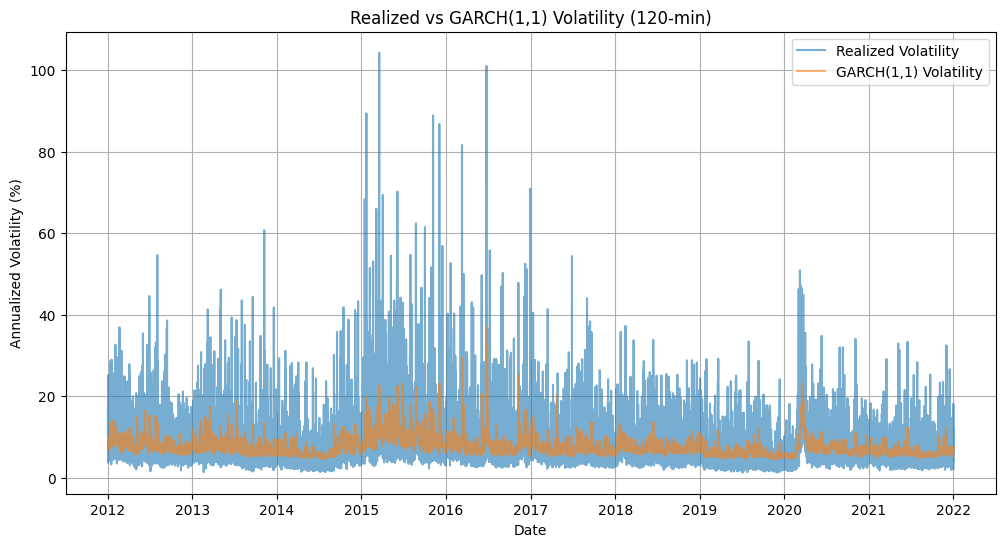

In [ ]:
# Prepare data
data = CC_120m_rvol.copy()
returns = data['Log_Returns_global'].dropna() * 100  # Scale for stability

# Fit ARCH(1)
arch_model_1 = arch_model(returns, vol='ARCH', p=1, rescale=False)
arch_fit = arch_model_1.fit(disp='off')
print(arch_fit.summary())

# Fit GARCH(1,1)
garch_model = arch_model(returns, vol='GARCH', p=1, q=1, rescale=False)
garch_fit = garch_model.fit(disp='off')
print(garch_fit.summary())

# Extract conditional volatility (annualized)
arch_vol = arch_fit.conditional_volatility * np.sqrt(252 * 12)  # 12 periods/day
garch_vol = garch_fit.conditional_volatility * np.sqrt(252 * 12)

# Compare with realized volatility
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['RVol_120min_Close-to-Close'], label='Realized Volatility', alpha=0.6)
plt.plot(data.index, garch_vol, label='GARCH(1,1) Volatility', alpha=0.6)
plt.title('Realized vs GARCH(1,1) Volatility (120-min)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid(True)
plt.show()

In [90]:
# Calculate 720-min and 2880-min realized volatility
data['RVol_720min_Close-to-Close'] = data['Log_Returns_global'].rolling(window=720).apply(
    lambda x: np.sqrt(np.sum(x**2) * (252 * 2)) * 100, raw=True
)
data['RVol_2880min_Close-to-Close'] = data['Log_Returns_global'].rolling(window=2880).apply(
    lambda x: np.sqrt(np.sum(x**2) * (252 * 0.5)) * 100, raw=True
)

# Split into subperiods
subperiods = {
    '2012-2020': data.loc['2012':'2020'],
    '2020-2023': data.loc['2020':'2023']
}

# Fit GARCH(1,1) for each subperiod
for period, df in subperiods.items():
    returns = df['Log_Returns_global'].dropna() * 100
    garch_model = arch_model(returns, vol='GARCH', p=1, q=1, rescale=False)
    garch_fit = garch_model.fit(disp='off')
    print(f"\n{period} GARCH(1,1) Parameters:")
    print(garch_fit.params)


2012-2020 GARCH(1,1) Parameters:
mu         -0.000549
omega       0.000442
alpha[1]    0.050002
beta[1]     0.929998
Name: params, dtype: float64

2020-2023 GARCH(1,1) Parameters:
mu         -0.000261
omega       0.000256
alpha[1]    0.040499
beta[1]     0.943289
Name: params, dtype: float64


In [91]:
# Identify crisis periods (using your spike detection)
crisis_periods = data[data['is_spike'] == True].index

# Fit GARCH(1,1) on crisis vs. non-crisis data
crisis_data = data.loc[data.index.isin(crisis_periods)]
non_crisis_data = data.loc[~data.index.isin(crisis_periods)]

for subset, label in [(crisis_data, 'Crisis'), (non_crisis_data, 'Non-Crisis')]:
    returns = subset['Log_Returns_global'].dropna() * 100
    garch_model = arch_model(returns, vol='GARCH', p=1, q=1, rescale=False)
    garch_fit = garch_model.fit(disp='off')
    persistence = garch_fit.params['alpha[1]'] + garch_fit.params['beta[1]']
    print(f"{label} Persistence (α + β): {persistence:.4f}")

KeyError: 'is_spike'

In [ ]:
######################################### CLEAN CODE ##########################################
###############################################################################################
###############################################################################################

Loaded 369,502 rows
                 0        1        2        3        4  5
0  20210103 170000  1.22396  1.22396  1.22373  1.22395  0
1  20210103 170100  1.22387  1.22420  1.22385  1.22395  0
2  20210103 170200  1.22396  1.22398  1.22382  1.22382  0
3  20210103 170300  1.22383  1.22396  1.22376  1.22378  0
4  20210103 170400  1.22378  1.22385  1.22296  1.22347  0
Index([0, 1, 2, 3, 4, 5], dtype='int64')


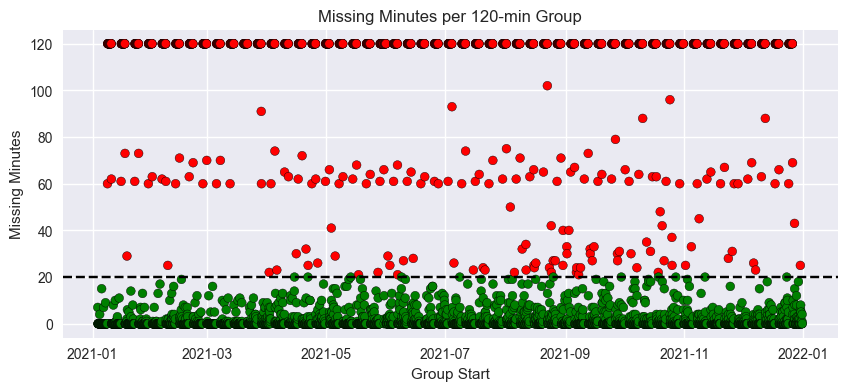

Final rVol dataset: 2993 rows


In [94]:
# =============================================================================
# 1. IMPORTS & SETTINGS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.optimize import minimize
from matplotlib.ticker import FuncFormatter


# Plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# =============================================================================
# 2. LOAD & CLEAN DATA
# =============================================================================
# --- Replace this path with your actual merged CSV ---
# List to store DataFrames
data_frames = []

# Loop through years 2012 to 2021
for year in range(2012, 2022):
    file_path = os.path.join(base_path, f'DAT_ASCII_EURUSD_M1_{year}.csv')
    
    # Read CSV file (adjust parameters if needed)
    df = pd.read_csv(file_path, header=None, sep=';')

# Copy and inspect
df = pd.read_csv(file_path, header=None, sep=';').copy()
print(f"Loaded {len(df):,} rows")
print(df.head())
print(df.columns)

# --- Standardize column names ---
df.columns = ['DateTime', 'Open', 'High', 'Low', 'Close', 'Volume']
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Set index and sort
df.set_index('DateTime', inplace=True)
df.sort_index(inplace=True)

# --- Add indicator: 1 if any OHLC missing ---
df['indicator'] = df[['Open', 'High', 'Low', 'Close']].isna().any(axis=1).astype(int)

# =============================================================================
# 3. REMOVE DUPLICATES & FILL GAPS
# =============================================================================
def remove_duplicate_timestamps(df):
    """Keep only first occurrence of duplicate timestamps."""
    df = df.loc[~df.index.duplicated(keep='first')]
    return df

def remove_consecutive_duplicates(df):
    """Remove flat or consecutive identical OHLC bars."""
    df = df.copy()
    dup = (
        (df['Open'] == df['Open'].shift(1)) &
        (df['High'] == df['High'].shift(1)) &
        (df['Low'] == df['Low'].shift(1)) &
        (df['Close'] == df['Close'].shift(1))
    ) | (
        (df['Open'] == df['Open'].shift(-1)) &
        (df['High'] == df['High'].shift(-1)) &
        (df['Low'] == df['Low'].shift(-1)) &
        (df['Close'] == df['Close'].shift(-1))
    )
    df.loc[dup, ['Open','High','Low','Close']] = np.nan
    df.loc[dup, 'Volume'] = 0
    df.loc[dup, 'indicator'] = 1
    return df

# Apply cleaning
df = remove_duplicate_timestamps(df)
df = remove_consecutive_duplicates(df)

# --- Create complete 1-minute index ---
full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='T')
df = df.reindex(full_idx)

# Fill missing OHLC with forward fill (optional: or interpolate)
df[['Open','High','Low','Close']] = df[['Open','High','Low','Close']].ffill()
df['Volume'] = df['Volume'].fillna(0)
df['indicator'] = df['indicator'].fillna(1)  # missing = flagged

# =============================================================================
# 4. REALIZED VOLATILITY CALCULATION (Close-to-Close)
# =============================================================================
def filter_incomplete_groups(ohlc_data, timeframe, threshold):
    """Drop groups with > threshold% missing data."""
    ohlc = ohlc_data.copy()
    ohlc['group_id'] = ohlc.index.floor(f'{timeframe}T')
    missing_thresh = timeframe * threshold
    valid_thresh = timeframe - missing_thresh

    missing_counts = ohlc.groupby('group_id')['indicator'].sum()
    passed = missing_counts <= missing_thresh

    plt.figure(figsize=(10,4))
    plt.scatter(missing_counts.index, missing_counts.values,
                c=['green' if ok else 'red' for ok in passed], s=40, edgecolor='k')
    plt.axhline(missing_thresh, color='black', linestyle='--')
    plt.title(f"Missing Minutes per {timeframe}-min Group")
    plt.xlabel("Group Start"); plt.ylabel("Missing Minutes")
    plt.show()

    valid_groups = passed[passed].index
    return ohlc[ohlc['group_id'].isin(valid_groups)].copy()

def compute_log_returns(df):
    """Add log returns and previous close."""
    df['Prev_Close'] = df['Close'].shift(1)
    df['Prev_Close'].fillna(df['Open'], inplace=True)
    df['Log_Returns'] = np.log(df['Close'] / df['Prev_Close'])
    return df

def calculate_rvol_ctc(df, timeframe=120, threshold=0.1667):
    """Main function: 120-min realized volatility (Close-to-Close)."""
    df = compute_log_returns(df)
    df = filter_incomplete_groups(df, timeframe, threshold)
    df['group_id'] = df.index.floor(f'{timeframe}T')

    # Variance per bar
    df['V'] = df['Log_Returns'] ** 2

    # Sum variance per group
    grp = df.groupby('group_id')['V'].agg(sum='sum', count='count')
    grp['var'] = grp['sum']
    rvol = np.sqrt(grp['var']) * np.sqrt(365 * 24 * 60 / timeframe) * 100  # Annualized %

    df['RVol_120min_Close-to-Close'] = df['group_id'].map(rvol)
    df['Prev_vol'] = df['RVol_120min_Close-to-Close'].shift(1)

    # Collapse to one row per group
    result = df.groupby('group_id').agg({
        'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last',
        'Volume': 'sum', 'indicator': 'sum',
        'RVol_120min_Close-to-Close': 'mean',
        'Prev_vol': 'mean'
    }).reset_index()
    result.rename(columns={'group_id': 'EndDateTime'}, inplace=True)
    result['StartDateTime'] = result['EndDateTime'] - pd.Timedelta(minutes=timeframe)
    return result

# Run pipeline
CC_120m_rvol = calculate_rvol_ctc(df, timeframe=120, threshold=0.1667)
print(f"Final rVol dataset: {len(CC_120m_rvol)} rows")

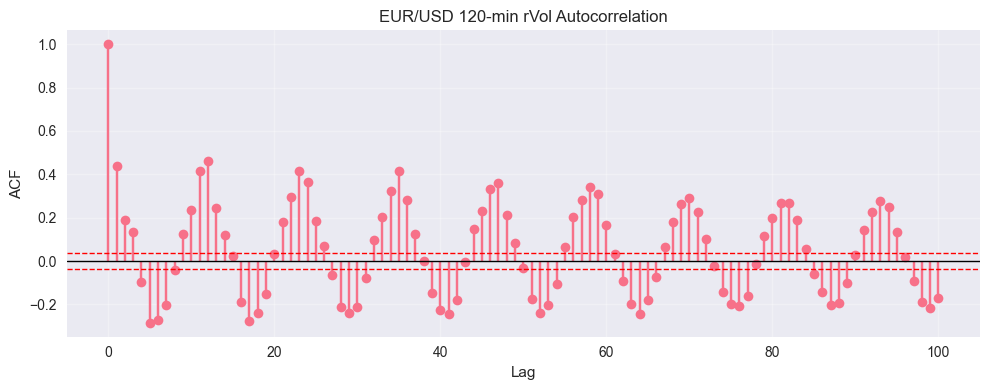

In [95]:
# =============================================================================
# 5. AUTOCORRELATION FUNCTION (FIXED!)
# =============================================================================
def acf_manual(y, max_lag=None, unbiased=False):
    """Compute sample ACF manually. Returns (lags, r)."""
    y = np.asarray(y, dtype=float).ravel()
    N = len(y)
    if N < 2: raise ValueError("Need ≥2 observations")
    if max_lag is None or max_lag >= N: max_lag = N - 1

    ybar = y.mean()
    denom = np.sum((y - ybar)**2)
    if denom == 0:
        return np.arange(max_lag+1), np.concatenate([[1], np.zeros(max_lag)])

    r = np.empty(max_lag + 1)
    r[0] = 1.0
    for k in range(1, max_lag + 1):
        num = np.sum((y[:-k] - ybar) * (y[k:] - ybar))
        r[k] = (num / (N - k)) / (denom / N) if unbiased else num / denom
    return np.arange(max_lag + 1), r

def plot_acf(y, max_lag=100, title="ACF"):
    lags, r = acf_manual(y, max_lag)
    plt.figure(figsize=(10,4))
    plt.stem(lags, r, basefmt=" ", linefmt="C0-", markerfmt="C0o")
    plt.axhline(0, color='k', linewidth=1)
    conf = 1.96 / np.sqrt(len(y))
    plt.axhline(conf, color='r', linestyle='--', linewidth=1)
    plt.axhline(-conf, color='r', linestyle='--', linewidth=1)
    plt.title(title); plt.xlabel("Lag"); plt.ylabel("ACF")
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Plot ACF
plot_acf(CC_120m_rvol['RVol_120min_Close-to-Close'].dropna(), max_lag=100,
         title="EUR/USD 120-min rVol Autocorrelation")

In [96]:
# =============================================================================
# 6. FILTER BY HOUR (e.g., London Open)
# =============================================================================
def filter_by_hour(df, hour):
    """Filter rows where StartDateTime hour == hour."""
    return df[pd.to_datetime(df['StartDateTime']).dt.hour == hour]

df_0800 = filter_by_hour(CC_120m_rvol, 8)
df_1200 = filter_by_hour(CC_120m_rvol, 12)

In [97]:
# =============================================================================
# 7. PREDICTED VOLATILITY (Previous + Decayed Slot)
# =============================================================================
def add_predicted_vol(df, vol_col='RVol_120min_Close-to-Close', alpha=0.3, decay=0.9, max_days=1):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['StartDateTime']).dt.date
    df['Slot'] = pd.to_datetime(df['StartDateTime']).dt.time

    slot_map = df.set_index(['Date', 'Slot'])[vol_col].to_dict()
    decayed = []

    for _, row in df.iterrows():
        cur_date, cur_slot = row['Date'], row['Slot']
        w_sum = vol_sum = 0
        for n in range(1, max_days + 1):
            past = cur_date - pd.Timedelta(days=n)
            key = (past, cur_slot)
            if key in slot_map:
                w = decay ** (n - 1)
                vol_sum += slot_map[key] * w
                w_sum += w
        decayed.append(vol_sum / w_sum if w_sum > 0 else np.nan)
    df['Decayed_Slot_Vol'] = decayed
    df['Prev_Vol'] = df[vol_col].shift(1)
    df['Pred_Var'] = alpha * (df['Prev_Vol']**2) + (1 - alpha) * (df['Decayed_Slot_Vol']**2)
    df['Predicted_Vol'] = np.sqrt(df['Pred_Var'])
    return df

Detected 149 volatility spikes


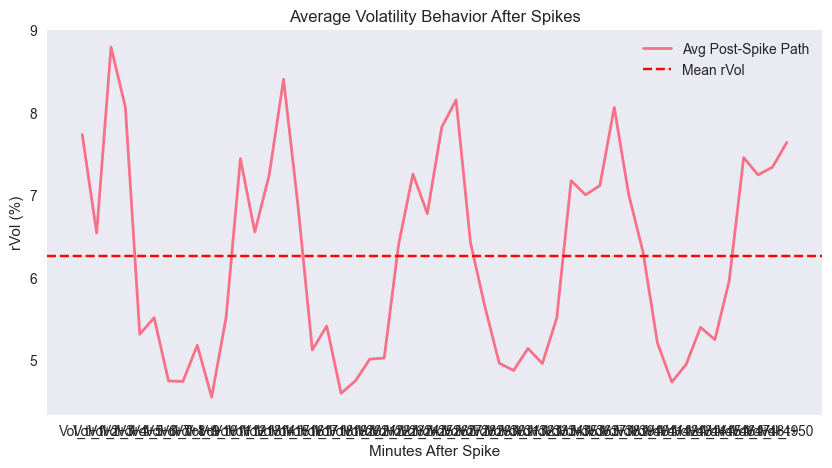

In [98]:
# =============================================================================
# 8. SPIKE DETECTION & POST-SPIKE BEHAVIOR
# =============================================================================
def detect_vol_spikes(df, vol_col, std_threshold=2, n_forward=50):
    df = df.copy()
    df['vol_change'] = df[vol_col].pct_change() * 100
    mean_c, std_c = df['vol_change'].mean(), df['vol_change'].std()
    threshold = mean_c + std_threshold * std_c
    spikes = df[df['vol_change'] > threshold].index

    paths = []
    for idx in spikes:
        if idx + n_forward < len(df):
            path = df.loc[idx+1:idx+n_forward, vol_col].values
            paths.append(path)
    cols = [f'Vol_t+{i+1}' for i in range(n_forward)]
    return pd.DataFrame(paths, columns=cols)

spikes_df = detect_vol_spikes(CC_120m_rvol, 'RVol_120min_Close-to-Close')
print(f"Detected {len(spikes_df)} volatility spikes")

# Plot average path
plt.figure(figsize=(10,5))
plt.plot(spikes_df.mean(), label='Avg Post-Spike Path', linewidth=2)
plt.axhline(CC_120m_rvol['RVol_120min_Close-to-Close'].mean(), color='r', linestyle='--', label='Mean rVol')
plt.title("Average Volatility Behavior After Spikes")
plt.xlabel("Minutes After Spike"); plt.ylabel("rVol (%)")
plt.legend(); plt.grid(); plt.show()

In [99]:
# =============================================================================
# 9. ROLLING BACKTEST (Parameter Stability)
# =============================================================================
def rolling_backtest(df, vol_col, months=3, max_days=1):
    df = df.copy()
    df['month'] = pd.to_datetime(df['StartDateTime']).dt.to_period('M')
    groups = df['month'].unique()
    results = []

    for i in range(len(groups)-1):
        train = df[df['month'] == groups[i]]
        test = df[df['month'] == groups[i+1]]

        if len(train) < 10 or len(test) < 10: continue

        # Optimize alpha
        def obj(alpha):
            train_pred = add_predicted_vol(train, vol_col=vol_col, alpha=alpha[0], max_days=max_days)
            ratio = np.log(train_pred[vol_col] / train_pred['Predicted_Vol'])
            return ratio.std()

        res = minimize(obj, x0=[0.5], bounds=[(0.01, 0.99)], method='L-BFGS-B')
        alpha_opt = res.x[0]

        # Test
        test_pred = add_predicted_vol(test, vol_col=vol_col, alpha=alpha_opt, max_days=max_days)
        test_ratio = np.log(test_pred[vol_col] / test_pred['Predicted_Vol'])
        test_std = test_ratio.std()

        results.append({
            'Train_Month': str(groups[i]),
            'Test_Month': str(groups[i+1]),
            'alpha': alpha_opt,
            'Test_Std': test_std
        })
    return pd.DataFrame(results)

backtest = rolling_backtest(CC_120m_rvol, 'RVol_120min_Close-to-Close')
print(backtest[['Train_Month', 'Test_Month', 'alpha', 'Test_Std']])

   Train_Month Test_Month     alpha  Test_Std
0      2021-01    2021-02  0.363189  0.267586
1      2021-02    2021-03  0.239475  0.304674
2      2021-03    2021-04  0.384917  0.309258
3      2021-04    2021-05  0.227280  0.334652
4      2021-05    2021-06  0.078630  0.340855
5      2021-06    2021-07  0.232960  0.349957
6      2021-07    2021-08  0.153902  0.288348
7      2021-08    2021-09  0.129608  0.349800
8      2021-09    2021-10  0.171506  0.258857
9      2021-10    2021-11  0.167255  0.414493
10     2021-11    2021-12  0.460821  0.345733


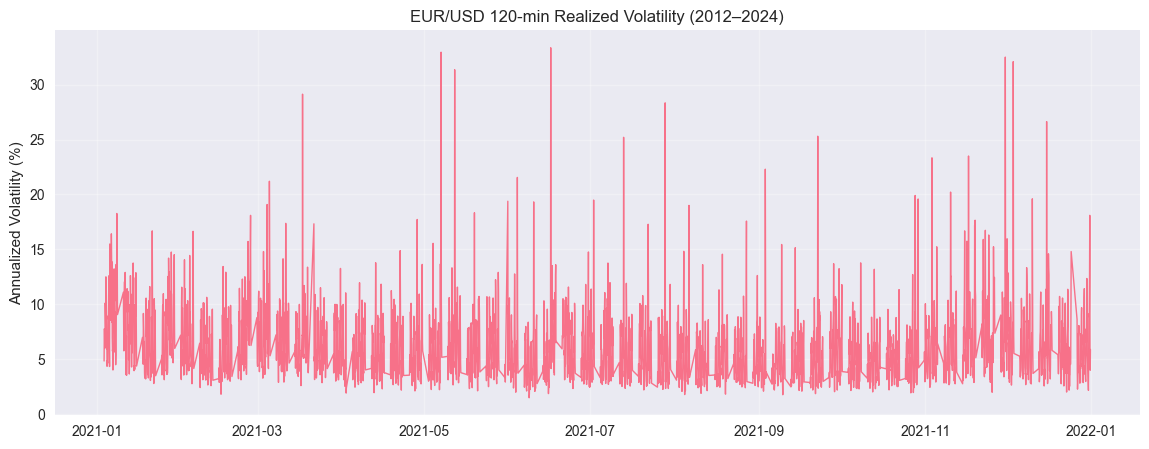

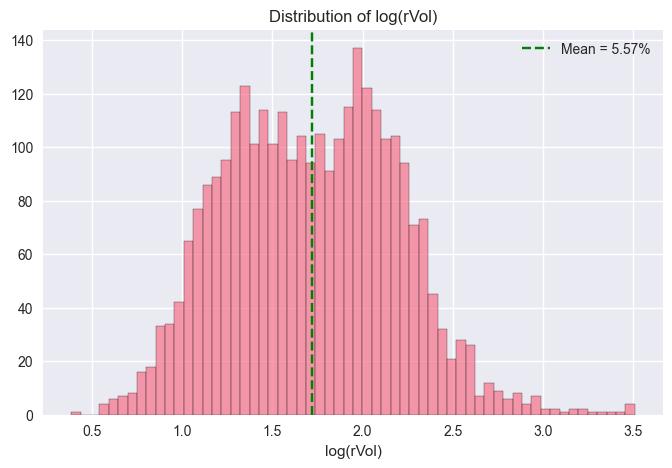

In [100]:
# =============================================================================
# 10. FINAL PLOTS
# =============================================================================
# 1. rVol Time Series
plt.figure(figsize=(14,5))
plt.plot(CC_120m_rvol['EndDateTime'], CC_120m_rvol['RVol_120min_Close-to-Close'], linewidth=1)
plt.title("EUR/USD 120-min Realized Volatility (2012–2024)")
plt.ylabel("Annualized Volatility (%)"); plt.grid(alpha=0.3); plt.show()

# 2. Histogram of log(rVol)
log_vol = np.log(CC_120m_rvol['RVol_120min_Close-to-Close'])
plt.figure(figsize=(8,5))
plt.hist(log_vol, bins=60, edgecolor='k', alpha=0.7)
plt.axvline(log_vol.mean(), color='g', linestyle='--', label=f"Mean = {np.exp(log_vol.mean()):.2f}%")
plt.title("Distribution of log(rVol)"); plt.xlabel("log(rVol)"); plt.legend(); plt.show()

In [101]:
######  ARCH/GARCH Introduction ########
# # Use your 120-min rVol series
vol_series = CC_120m_rvol.set_index('EndDateTime')['RVol_120min_Close-to-Close']
returns = np.log(vol_series.pct_change().dropna() + 1)  # Log returns of vol? No!

# WRONG: We model *returns*, not volatility
# CORRECT: Compute **intraday returns** from 120-min OHLC

def compute_120min_returns(df):
    df = df.copy()
    df['return'] = np.log(df['Close'] / df['Close'].shift(1))
    return df['return'].replace([np.inf, -np.inf], np.nan).dropna()

returns_120m = compute_120min_returns(CC_120m_rvol)
print(f"120-min returns: {len(returns_120m)} observations")

120-min returns: 2992 observations


In [102]:
####### Fit ARCH(1) and GARCH(1,1)  ################
# Scale returns to percent (for stability)
scaled_returns = returns_120m * 100

# --- ARCH(1) ---
arch1 = arch_model(scaled_returns, vol='ARCH', p=1, dist='normal')
res_arch1 = arch1.fit(disp='off')
print(res_arch1.summary())

# --- GARCH(1,1) ---
garch11 = arch_model(scaled_returns, vol='Garch', p=1, q=1, dist='normal')
res_garch11 = garch11.fit(disp='off')
print(res_garch11.summary())

# Extract conditional volatility
cond_vol_arch = res_arch1.conditional_volatility
cond_vol_garch = res_garch11.conditional_volatility

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                2641.87
Distribution:                  Normal   AIC:                          -5277.74
Method:            Maximum Likelihood   BIC:                          -5259.73
                                        No. Observations:                 2992
Date:                Wed, Oct 29 2025   Df Residuals:                     2991
Time:                        17:28:12   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -1.8060e-03  1.833e-03     -0.985      0.

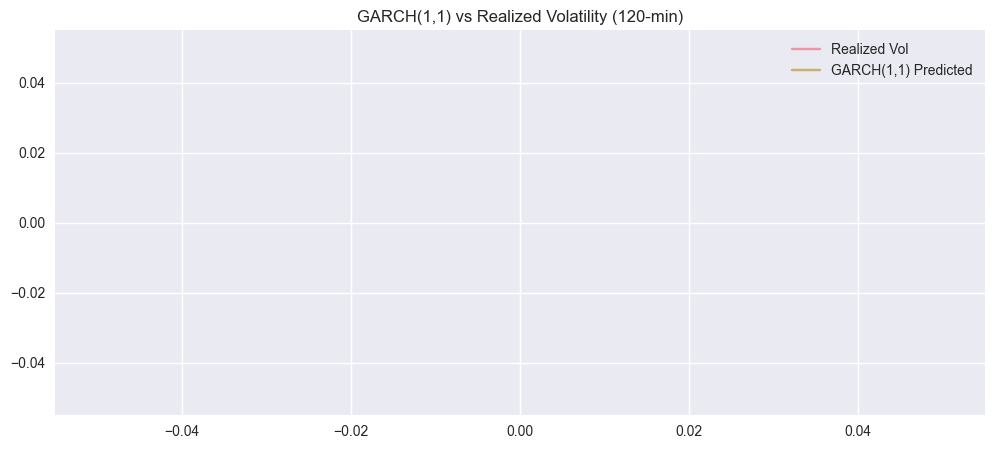

In [111]:
####################                Compare with Realized Volatility          ##############
# Align dates
common_idx = cond_vol_garch.index.intersection(vol_series.index)
realized = vol_series.loc[common_idx] / 100  # to decimal
predicted_garch = cond_vol_garch.loc[common_idx] / 100

plt.figure(figsize=(12,5))
plt.plot(common_idx, realized, label='Realized Vol', alpha=0.7)
plt.plot(common_idx, predicted_garch, label='GARCH(1,1) Predicted', alpha=0.7)
plt.title("GARCH(1,1) vs Realized Volatility (120-min)")
plt.legend(); plt.show()

In [104]:
####################### First Models & Stability Testing    #############################
# Split into subperiods
df = CC_120m_rvol.copy()
df['date'] = pd.to_datetime(df['EndDateTime']).dt.date

periods = {
    '2000-2010': (df['date'] >= pd.to_datetime('2000-01-01').date()) & (df['date'] < pd.to_datetime('2010-01-01').date()),
    '2010-2020': (df['date'] >= pd.to_datetime('2010-01-01').date()) & (df['date'] < pd.to_datetime('2020-01-01').date()),
    '2020-2023': (df['date'] >= pd.to_datetime('2020-01-01').date()) & (df['date'] < pd.to_datetime('2023-01-01').date())
}

results = []
for name, mask in periods.items():
    rets = compute_120min_returns(df[mask]) * 100
    if len(rets) < 100: continue
    model = arch_model(rets, vol='Garch', p=1, q=1).fit(disp='off')
    alpha, beta = model.params['alpha[1]'], model.params['beta[1]']
    results.append({
        'Period': name,
        'alpha': alpha,
        'beta': beta,
        'persistence': alpha + beta,
        'loglik': model.loglikelihood
    })

stability_df = pd.DataFrame(results)
print(stability_df)

      Period     alpha      beta  persistence       loglik
0  2020-2023  0.181965  0.016578     0.198544  2641.896809


In [109]:
#################   Parameter Optimization & Crisis vs Stable (2021 ONLY)   #################

# --- RECREATE DATE & VOL ---
df = CC_120m_rvol.copy()
df['EndDateTime'] = pd.to_datetime(df['EndDateTime'])
df['date'] = df['EndDateTime'].dt.date
vol = df['RVol_120min_Close-to-Close']

print(f"Data: {df['date'].min()} to {df['date'].max()} ({len(df)} rows)")

# --- Define regimes by volatility ---
crisis = vol >= vol.quantile(0.90)   # Top 10%
stable = vol <= vol.quantile(0.50)   # Bottom 50%

print(f"Crisis periods: {crisis.sum():,}")
print(f"Stable periods: {stable.sum():,}")

# --- Returns ---
crisis_rets = compute_120min_returns(df[crisis]) * 100
stable_rets = compute_120min_returns(df[stable]) * 100

# --- Fit GARCH ---
crisis_model = arch_model(crisis_rets.dropna(), vol='Garch', p=1, q=1).fit(disp='off')
stable_model = arch_model(stable_rets.dropna(), vol='Garch', p=1, q=1).fit(disp='off')

# --- Results ---
print(f"\nCrisis α+β: {crisis_model.params['alpha[1]'] + crisis_model.params['beta[1]']:.4f}")
print(f"Stable α+β: {stable_model.params['alpha[1]'] + stable_model.params['beta[1]']:.4f}")

Data: 2021-01-03 to 2021-12-31 (2993 rows)
Crisis periods: 300
Stable periods: 1,497

Crisis α+β: 0.9896
Stable α+β: 0.9868


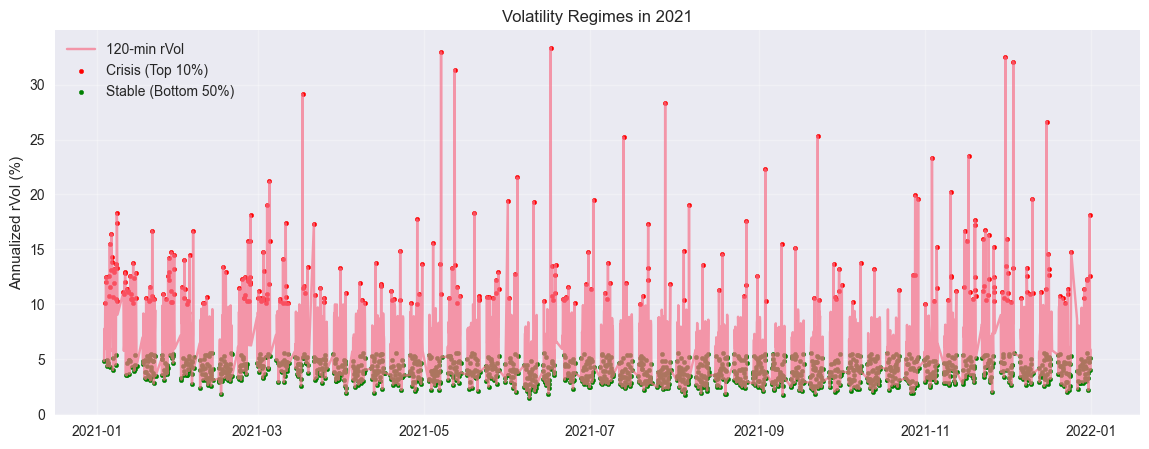

In [110]:
plt.figure(figsize=(14,5))
plt.plot(df['EndDateTime'], vol, label='120-min rVol', alpha=0.7)
plt.scatter(df['EndDateTime'][crisis], vol[crisis], color='red', s=10, label='Crisis (Top 10%)')
plt.scatter(df['EndDateTime'][stable], vol[stable], color='green', s=10, label='Stable (Bottom 50%)')
plt.title("Volatility Regimes in 2021")
plt.ylabel("Annualized rVol (%)"); plt.legend(); plt.grid(alpha=0.3); plt.show()

In [112]:
############################    Model Variants (EGARCH, TGARCH) ##########################################
# EGARCH(1,1) - captures asymmetry
egarch = arch_model(scaled_returns, vol='EGarch', p=1, o=1, q=1).fit(disp='off')
print(egarch.summary())

# TGARCH(1,1) - leverage effect
tgarch = arch_model(scaled_returns, vol='Garch', p=1, o=1, q=1).fit(disp='off')
print(tgarch.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:                2644.60
Distribution:                  Normal   AIC:                          -5279.21
Method:            Maximum Likelihood   BIC:                          -5249.19
                                        No. Observations:                 2992
Date:                Wed, Oct 29 2025   Df Residuals:                     2991
Time:                        18:45:23   Df Model:                            1
                                   Mean Model                                  
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -1.6490e-03  8.120e-04     -2.031  4.2

In [120]:
#############################   Correlation & Distribution Analysis   ############################

# --- 1. Returns with clean datetime index ---
df_returns = CC_120m_rvol.copy()
df_returns['EndDateTime'] = pd.to_datetime(df_returns['EndDateTime'])  # ← Ensure datetime
df_returns = df_returns.set_index('EndDateTime')

# Compute returns
df_returns['return'] = np.log(df_returns['Close'] / df_returns['Close'].shift(1))
returns_clean = df_returns['return'].dropna() * 100

# --- 2. Fit GARCH ---
garch_model = arch_model(returns_clean, vol='Garch', p=1, q=1, dist='normal')
garch_res = garch_model.fit(disp='off')
cond_vol_garch = garch_res.conditional_volatility

# --- 3. Realized vol with SAME index ---
vol_series = CC_120m_rvol.set_index('EndDateTime')['RVol_120min_Close-to-Close']
vol_series.index = pd.to_datetime(vol_series.index)  # ← Force datetime

# --- 4. Remove timezone (if any) ---
cond_vol_garch.index = cond_vol_garch.index.tz_localize(None)
vol_series.index = vol_series.index.tz_localize(None)

# --- 5. Align ---
common_idx = cond_vol_garch.index.intersection(vol_series.index)
print(f"Overlap: {len(common_idx)} points")

if len(common_idx) == 0:
    raise ValueError("Still no overlap! Check data.")

y_true = vol_series.loc[common_idx] / 100
y_pred = cond_vol_garch.loc[common_idx] / 100

Overlap: 2992 points


In [118]:
# --- Metrics ---
corr = np.corrcoef(y_true, y_pred)[0,1]
r2 = corr ** 2
residuals = y_true - y_pred

print(f"\nCorrelation: {corr:.4f}")
print(f"R²: {r2:.4f}")
print(f"Skew (residuals): {skew(residuals):.4f}")
print(f"Kurtosis (residuals): {kurtosis(residuals):.4f}")


Correlation: 0.2100
R²: 0.0441
Skew (residuals): 2.2061
Kurtosis (residuals): 10.3048


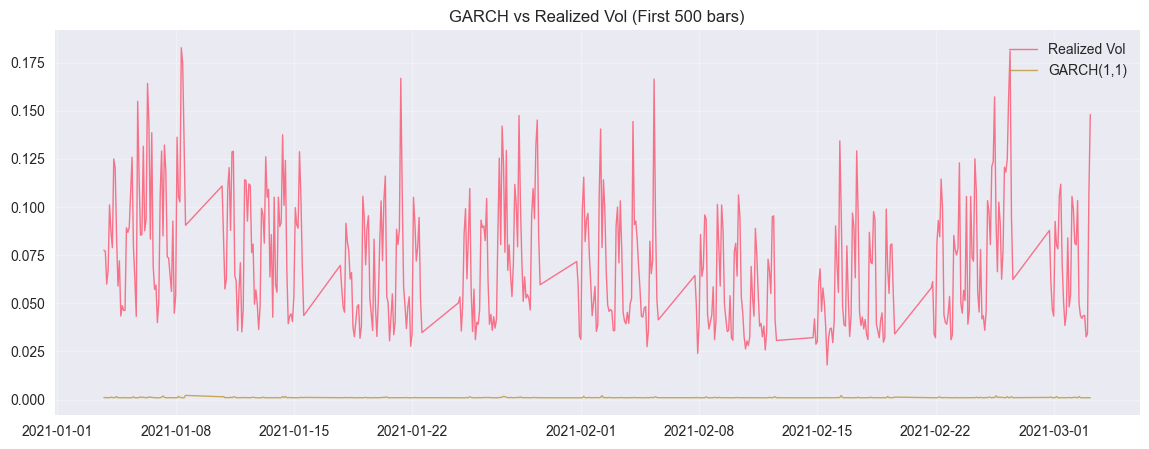

In [119]:
plt.figure(figsize=(14,5))
plt.plot(common_idx[:500], y_true.iloc[:500], label='Realized Vol', linewidth=1)
plt.plot(common_idx[:500], y_pred.iloc[:500], label='GARCH(1,1)', linewidth=1, alpha=0.8)
plt.title("GARCH vs Realized Vol (First 500 bars)")
plt.legend(); plt.grid(alpha=0.3); plt.show()